 <font size="10">**Notebook 06: scVI integration of Whole Embryo scRNA-seq data: part 3**</font>
***

<div class="alert alert-info">
    
<b> <h1> ℹ️ <strong> <font size="6" color="black"> Important notebook information </font> </strong> </h1> </b>
    <hr>
    <font size="4" color="black">
        The purpose of this notebook is to generate a scVI model to integrate the Whole Embryo scRNA-seq data  <br> <br>
    This notebook will take into account both donor and chemistry as batch covariates to correct for as these have been show to qualatatively introduce the most technical batch  <br> <br>
    This notebook is to be re-run varying the number of latent spaces and batch size <br> <br>
    The scoring done at the end of this notebook will be compared in  Notebook 06: scVI integration of Whole Embryo scRNA-seq data: part2  <br> <br>
    </font>
    
<details>
    <summary> <font size="4" color="black"> Models to be generated for comparison in Notebook 06: batch correction assessment </font> </summary> <br/>
    <font size="3" color="black"> Table below will summarise all the models made for scoring:<br> <br> </font> 
    <table style="margin-top:10px; margin-left:50px;">
        <tr>
            <th>Model number</th>
            <th>No. latent spaces</th>
            <th>Batch size</th>
        </tr>
        <tr>
            <td>1</td>
            <td>10</td>
            <td>1024</td>
        </tr>
        <tr>
            <td>2</td>
            <td>20</td>
            <td>1024</td>
        </tr>
        <tr>
            <td>3</td>
            <td>30</td>
            <td>1024</td>
        </tr>
        <tr>
            <td>4</td>
            <td>10</td>
            <td>3000</td>
        </tr>
        <tr>
            <td>5</td>
            <td>20</td>
            <td>3000</td>
        </tr>
        <tr>
            <td>6</td>
            <td>30</td>
            <td>3000</td>
        </tr>
        <tr>
            <td>7</td>
            <td>10</td>
            <td>5000</td>
        </tr>
        <tr>
            <td>8</td>
            <td>20</td>
            <td>5000</td>
        </tr>
        <tr>
            <td>9</td>
            <td>30</td>
            <td>5000</td>
        </tr>
    </table> <br>
    <font size="3" color="black"> The scVI latent spaces will be compared by scoring a resultant KNN graph with set number of neighbours to reduce computational load and time</font> 
</details> <br> <br>
    
<font size="4" color="black">
        After an optinum model is selected, an appropriate number of neighbours will be determined using the same scoring metrics  <br> <br>
    </font>

# Import packages

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import sys
import matplotlib.pyplot as plt
from kneed import KneeLocator
import tqdm
import pickle
from sklearn.metrics import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import datetime
import os

#to set unique date for outputs
calc_date = datetime.datetime.now()
date=calc_date.strftime('%Y-%m-%d')
#date=calc_date.strftime('%d-%m-%Y')
date = date.replace('-', '')

Global seed set to 0


# What am I going to vary:

- Main things I think will affect model output: gene input, number of latent spaces, batch sizes 

- Gene input sticking with top 10,000 genes
- Keep donor as main batch and chemistry as additional categorical for now - lane isn't much batch affect intra sections and want to preserve intersections differences so donor makes more sense to me
- Min batch (donor) size is around 300,000 cells 
- From previous runs model always converges before 400 epochs so sticking to 400 with early stopping parameter



- Want to vary the number of latent spaces (d')(d prime)
    - 10, 20, 30
- Want to vary the batch size (k)
    - 1024, 3000, 5000

# User settings interaction block 

In [2]:
name = 'adata_subset_10000'
batch_key = "haniffa_ID"
categorical_covariate_keys=['10x_kit']
latent = 20   # 10, 20, 30
batch_size = 3000   #1024, 3000, 5000

model = batch_key + '_ext_cat_' + categorical_covariate_keys[0] + '_latent_' + str(latent) + '_batch_size_' + str(batch_size)
model

'haniffa_ID_ext_cat_10x_kit_latent_20_batch_size_3000'

# Read in the appropriate data

In [3]:
adata = sc.read('/home/jupyter/mount/sanger_gdrive/whole_embryo/SCVI_for_n_3_20220513/n_3_log_norm_{n}_top_gene_dispersion_norm_for_SCVI_input_20220513.h5ad'.format(n=name))

# Define and generate a scVI vae model for batch correction purposes

In [4]:
adata_input = scvi.model.SCVI.setup_anndata(adata, layer="raw_counts", batch_key=batch_key, categorical_covariate_keys = categorical_covariate_keys,copy=True)

INFO     Using batches from adata.obs["haniffa_ID"]                                          
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["raw_counts"]                                          
INFO     Successfully registered anndata object containing 1138964 cells, 10000 vars, 3      
         batches, 1 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


In [5]:
vae = scvi.model.SCVI(adata_input, n_latent=latent, n_hidden=256)

In [6]:
vae.train(early_stopping=True,
        train_size=0.9,
        early_stopping_patience=45,
        max_epochs=400, 
        batch_size=batch_size, 
        limit_train_batches=20)

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

/opt/conda/envs/Python_env_Hlab/lib/python3.9/site-packages/scvi/distributions/_negative_binomial.py:56: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is /home/jupyter/.cache/torch/kernels. This warning will appear only once per process. (Triggered internally at  ../aten/src/ATen/native/cuda/jit_utils.cpp:860.)
  + torch.lgamma(x + theta)


Epoch 400/400: 100%|██████████| 400/400 [2:01:55<00:00, 18.29s/it, loss=1.97e+03, v_num=1]   


# Check model

Elbow point for elbo_train around: 14 epochs | elbow score for y axis: 2178.1123046875

Elbow point for elbo_validation around: 32 epochs | elbow score for y axis: 2115.28271484375



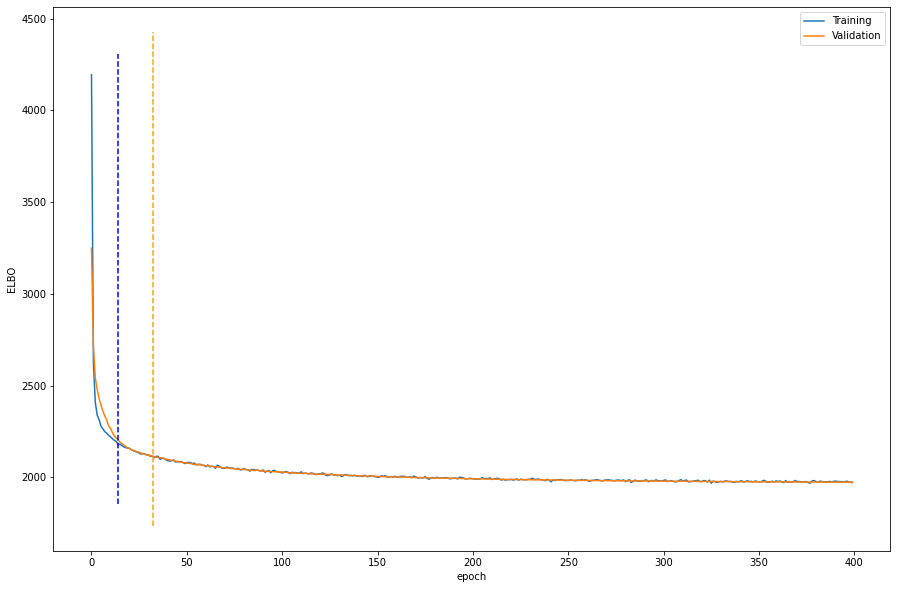

In [7]:
epochs = np.arange(len(vae.history["elbo_train"]))

kn1 = KneeLocator(epochs, vae.history["elbo_train"]["elbo_train"].values, curve='convex', direction='decreasing')
kn2 = KneeLocator(epochs, vae.history["elbo_validation"]["elbo_validation"].values, curve='convex', direction='decreasing')

plt.figure(figsize=(15,10))

plt.plot(vae.history["elbo_train"], label="Training")
plt.plot(vae.history["elbo_validation"], label="Validation")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("ELBO")

plt.vlines(kn1.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', color='blue')
plt.vlines(kn2.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', color='orange')

print('\033[1m' + f'Elbow point for elbo_train around: {round(kn1.knee, 3)} epochs | elbow score for y axis: {kn1.elbow_y}'+ '\033[0m')
print("")
print('\033[1m' + f'Elbow point for elbo_validation around: {round(kn2.knee, 3)} epochs | elbow score for y axis: {kn2.elbow_y}'+ '\033[0m')
print("")

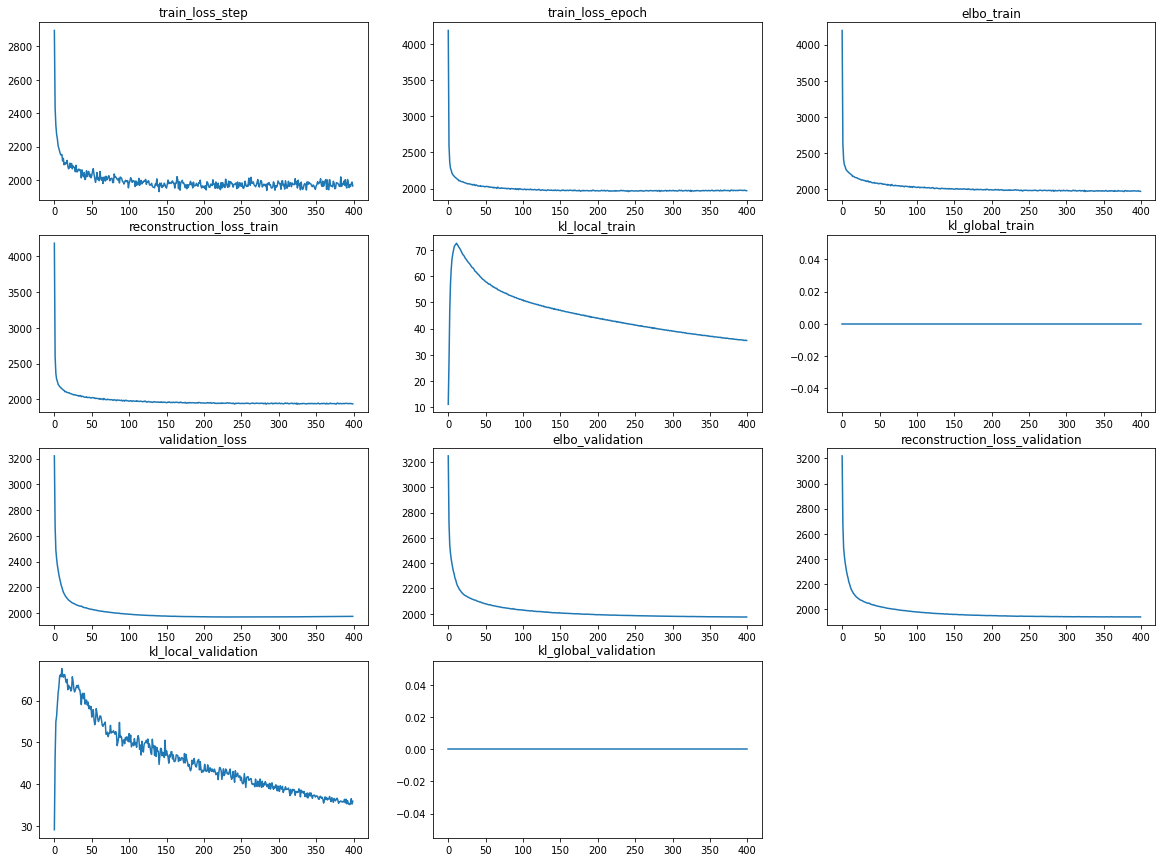

In [8]:
count=1
plt.subplots(figsize=(20, 15))
for key in vae.history.keys():
    plt.subplot(4,3,count)
    plt.plot(vae.history[key])
    plt.title(key)
    count+=1

plt.show()

In [9]:
vae.get_elbo()

tensor(-1968.0421)

In [10]:
vae.get_reconstruction_error()

{'reconstruction_loss': -1931.9761689543084}

In [11]:
Z_hat = vae.get_latent_representation()
for i, z in enumerate(Z_hat.T):
    adata.obs[f'Z_{i}'] = z

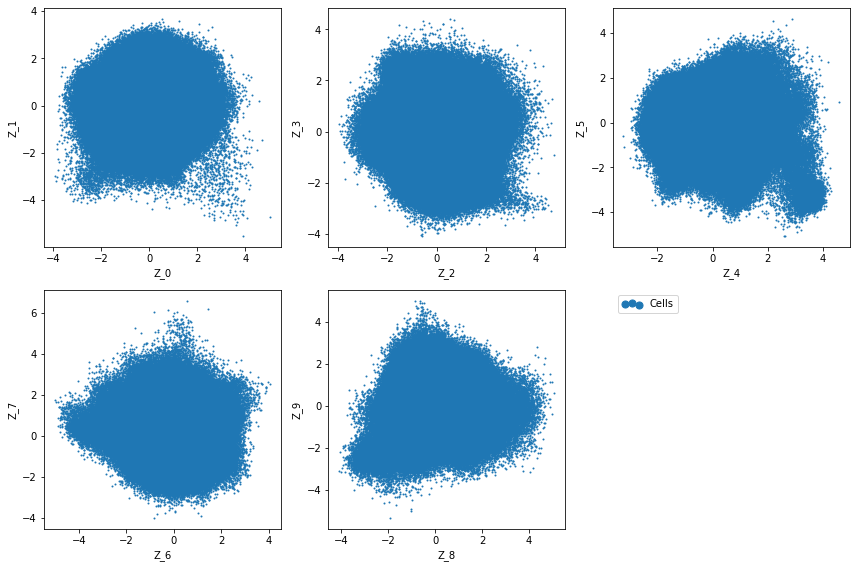

In [12]:
fig = plt.figure(figsize=(12, 8))

for f in range(0, 9, 2):
    plt.subplot(2, 3, int(f / 2) + 1)

    plt.scatter(adata.obs[f'Z_{f}'], adata.obs[f'Z_{f + 1}'], marker='.', s=4, label='Cells')

    plt.xlabel(f'Z_{f}')
    plt.ylabel(f'Z_{f + 1}')

plt.subplot(2, 3, 6)
plt.scatter(adata.obs[f'Z_{f}'], adata.obs[f'Z_{f + 1}'], marker='.', label='Cells', s=4)
plt.scatter(adata.obs[f'Z_{f}'], adata.obs[f'Z_{f + 1}'], c='w', label=None)
plt.gca().set_frame_on(False)
plt.gca().axis('off')

lgd = plt.legend(scatterpoints=3, loc='upper left')
for handle in lgd.legendHandles:
    handle.set_sizes([200])


plt.tight_layout()

# Save latent space into anndata object and save a copy of the model 

In [13]:
adata.obsm["X_scVI"] = vae.get_latent_representation()

In [14]:
cwd = os.getcwd()
new_dir = cwd + '/' + model + '_scvi_outs'
os.mkdir(new_dir)

In [15]:
adata.write(new_dir + '/n_3_scvi_run_{n}_{m}_{d}.h5ad'.format(n=name, m=model, d=date))

In [16]:
vae.save(new_dir + "/model_scvi_{n}_{m}_{d}/".format(n=name, m=model, d=date))

# Generate KNN graqphs for n_neighbours between 15 to 30 in increments of 5

In [ ]:
# perform main generations

neighbours = [15,20,25,30]

for n in tqdm.tqdm(neighbours):
    name = 'neighbours_' + str(n)
    sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=n, metric='euclidean', key_added=name)
    sc.tl.umap(adata, min_dist=0.5, spread=1.0, n_components=2, neighbors_key=name, random_state=0)
    leiden_name = name + '_leiden_res_0_5'
    sc.tl.leiden(adata, resolution=0.5, key_added=leiden_name, neighbors_key=name)
    leiden_name_2 = name + '_leiden_res_3'
    sc.tl.leiden(adata, resolution=3, key_added=leiden_name_2, neighbors_key=name)
    adata.obsm['X_umap_' + name] = adata.obsm['X_umap']
    #adata.obsp['connectivities' + name] =  adata.obsp['connectivities']
    #adata.obsp['distances' + name] =  adata.obsp['distances']
    
# make 15 the default
adata.obsm['X_umap'] = adata.obsm['X_umap_neighbours_15']
adata.obsp['connectivities'] =  adata.obsp['connectivities_neighbours_15']
adata.obsp['distances'] =  adata.obsp['distances_neighbours_15']

  0%|          | 0/4 [00:00<?, ?it/s]

# Save a copy of the anndata with KNN graphs

In [ ]:
adata.write(new_dir + '/n_3_scvi_run_{n}_{m}_{d}_with_umaps.h5ad'.format(n=name, m=model, d=date))

In [5]:
adata

AnnData object with n_obs × n_vars = 1138964 × 10000
    obs: 'dataset', 'sequencing_lane_ID', 'haniffa_ID', 'HDBR_ID', 'sequencing_type', '10x_kit', 'spatial_location', 'spatial_location_replicates', 'sort_ID', 'procedure', 'age_in_cs', 'sex', 'alignment_software', 'alignment_reference', 'cutoff_1.4826_is_doublet', 'cutoff_2_is_doublet', 'cutoff_3_is_doublet', 'nUMI', 'nGene', 'nCounts', 'percent.mito', 'percent.ribo', 'n_genes', 'n_counts', 'Z_0', 'Z_1', 'Z_2', 'Z_3', 'Z_4', 'Z_5', 'Z_6', 'Z_7', 'Z_8', 'Z_9', 'Z_10', 'Z_11', 'Z_12', 'Z_13', 'Z_14', 'Z_15', 'Z_16', 'Z_17', 'Z_18', 'Z_19', 'neighbours_15_leiden_res_0_5', 'neighbours_15_leiden_res_3', 'neighbours_20_leiden_res_0_5', 'neighbours_20_leiden_res_3', 'neighbours_25_leiden_res_0_5', 'neighbours_25_leiden_res_3', 'neighbours_30_leiden_res_0_5', 'neighbours_30_leiden_res_3'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highl

# Define directories for saving plot outputs

In [5]:
cwd = os.getcwd()
new_dir = cwd + '/' + model + '_scvi_outs'
save_dir = new_dir + '/plot_outputs/'
os.mkdir(save_dir)
umap_save_dir = save_dir + '/umaps/'
braplot_save_dir = save_dir + '/barplots/'
scoring_save_dir = save_dir + '/scoring/'
os.mkdir(umap_save_dir)
os.mkdir(braplot_save_dir)
os.mkdir(scoring_save_dir)

# Cycle through neighbourhoods generated from single scVI model to qualatatively observe metadata

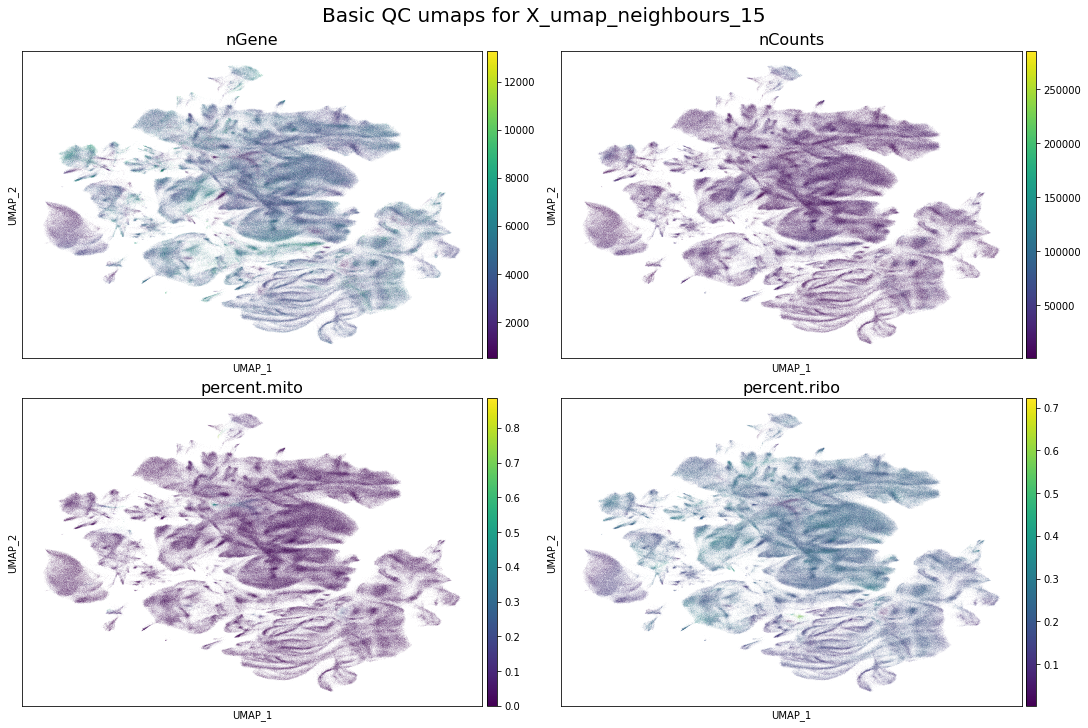

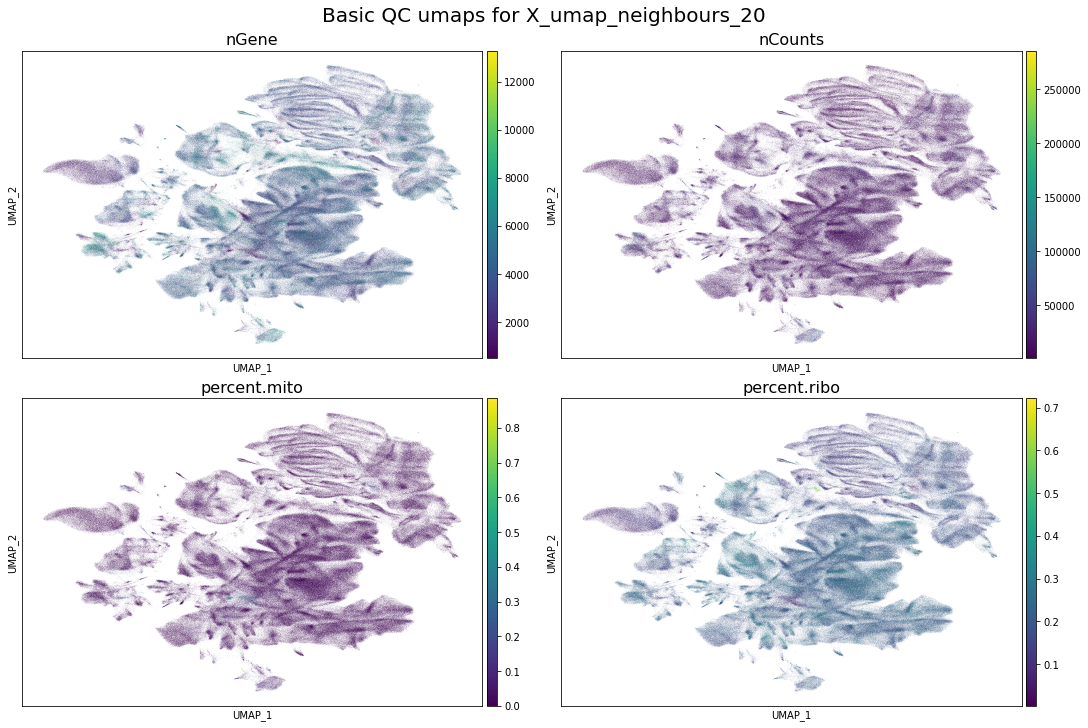

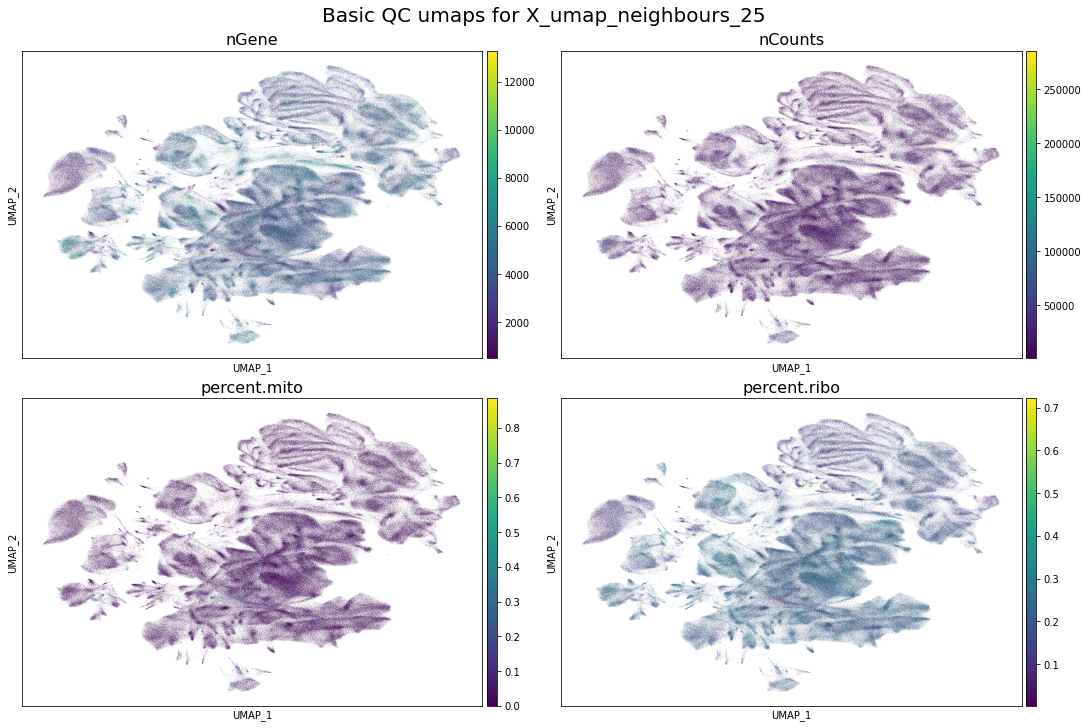

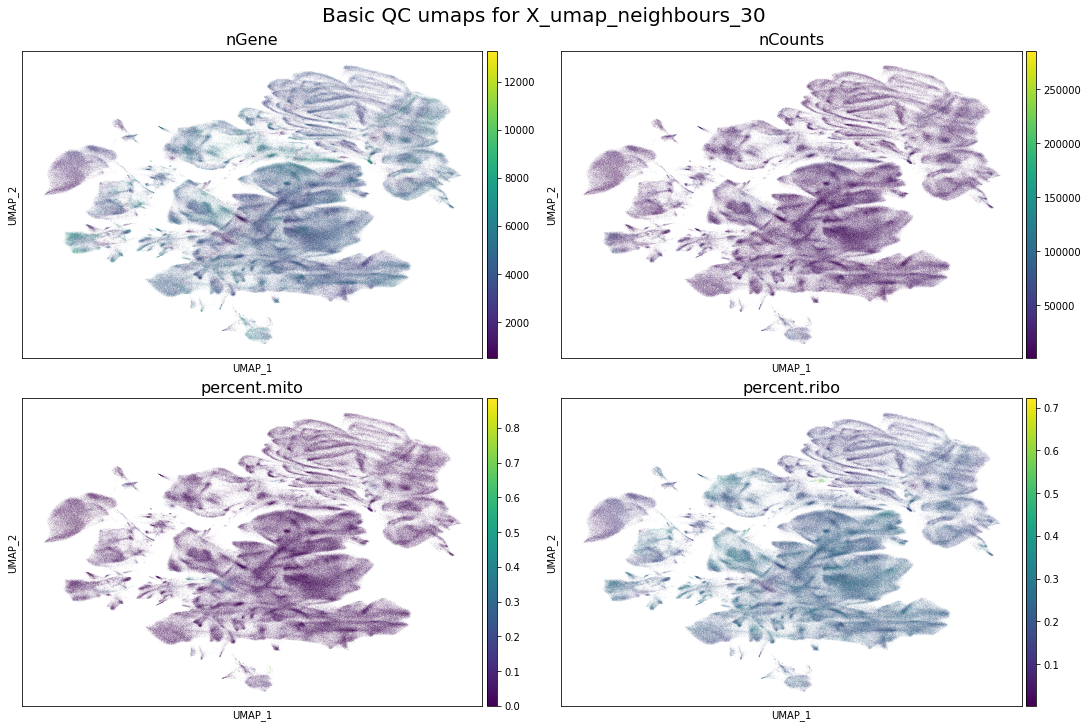

In [6]:
neighbourhoods = ['X_umap_neighbours_15', 'X_umap_neighbours_20', 'X_umap_neighbours_25', 'X_umap_neighbours_30']

for neighbourhood in neighbourhoods:

    basis = neighbourhood
    
    fig = plt.figure(constrained_layout=True, figsize=(15,10))
    
    ax1 = plt.subplot(2,2,1)
    color = 'nGene'
    sc.pl.embedding(adata, basis = basis, ax=ax1, show=False, title='', color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax2 = plt.subplot(2,2,2) 
    color = 'nCounts'
    sc.pl.embedding(adata, basis = basis, ax=ax2, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax3 = plt.subplot(2,2,3)
    color = 'percent.mito'
    sc.pl.embedding(adata, basis = basis, ax=ax3, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax4 = plt.subplot(2,2,4)
    color = 'percent.ribo'
    sc.pl.embedding(adata, basis = basis, ax=ax4, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    
    fig.suptitle('Basic QC umaps for ' + neighbourhood, fontsize=20)
    fig.set_constrained_layout_pads(w_pad=4 / 72, h_pad=4 / 72, hspace=0.2, wspace=0.2)
    fig.savefig(umap_save_dir + 'Basic_QC_umaps_for_' + neighbourhood + '.png', bbox_inches='tight', dpi=300) # pdf not working for some reason but as not for figures will make as pngs for now and if need make individual for 300 dpi
    #plt.savefig(save_dir+'Basic_QC_umaps_for_' + neighbourhood + '.pdf', bbox_inches='tight', dpi=80) # can open but blank ...
    plt.show()
    print("")
    print("")
    print("")
    print("")

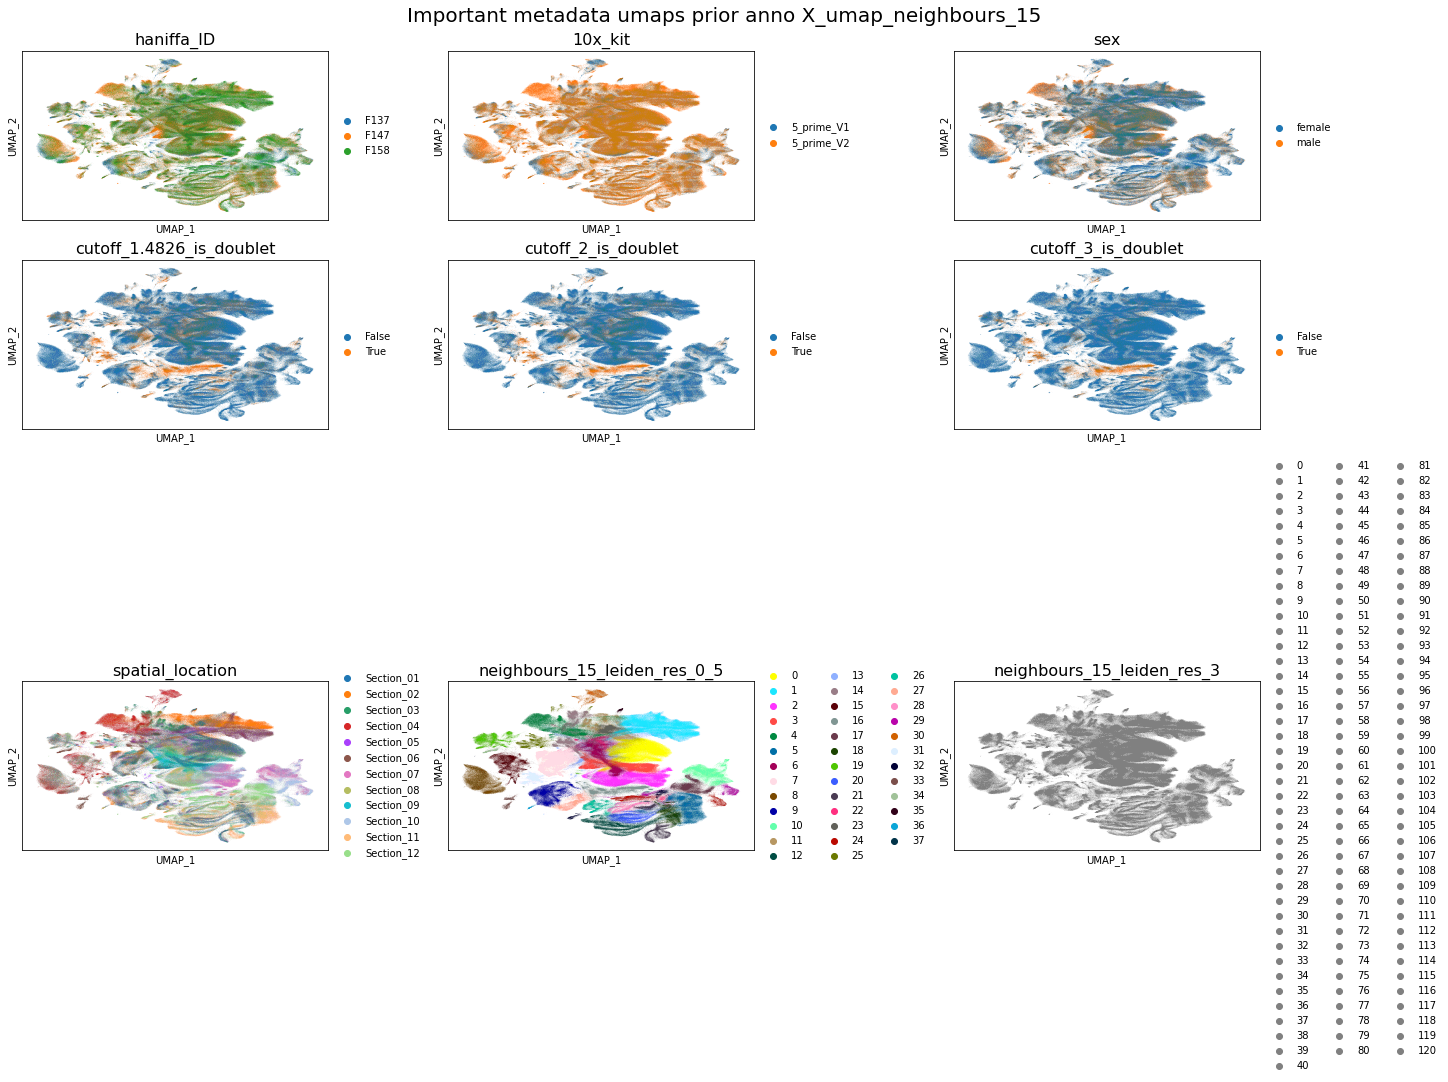

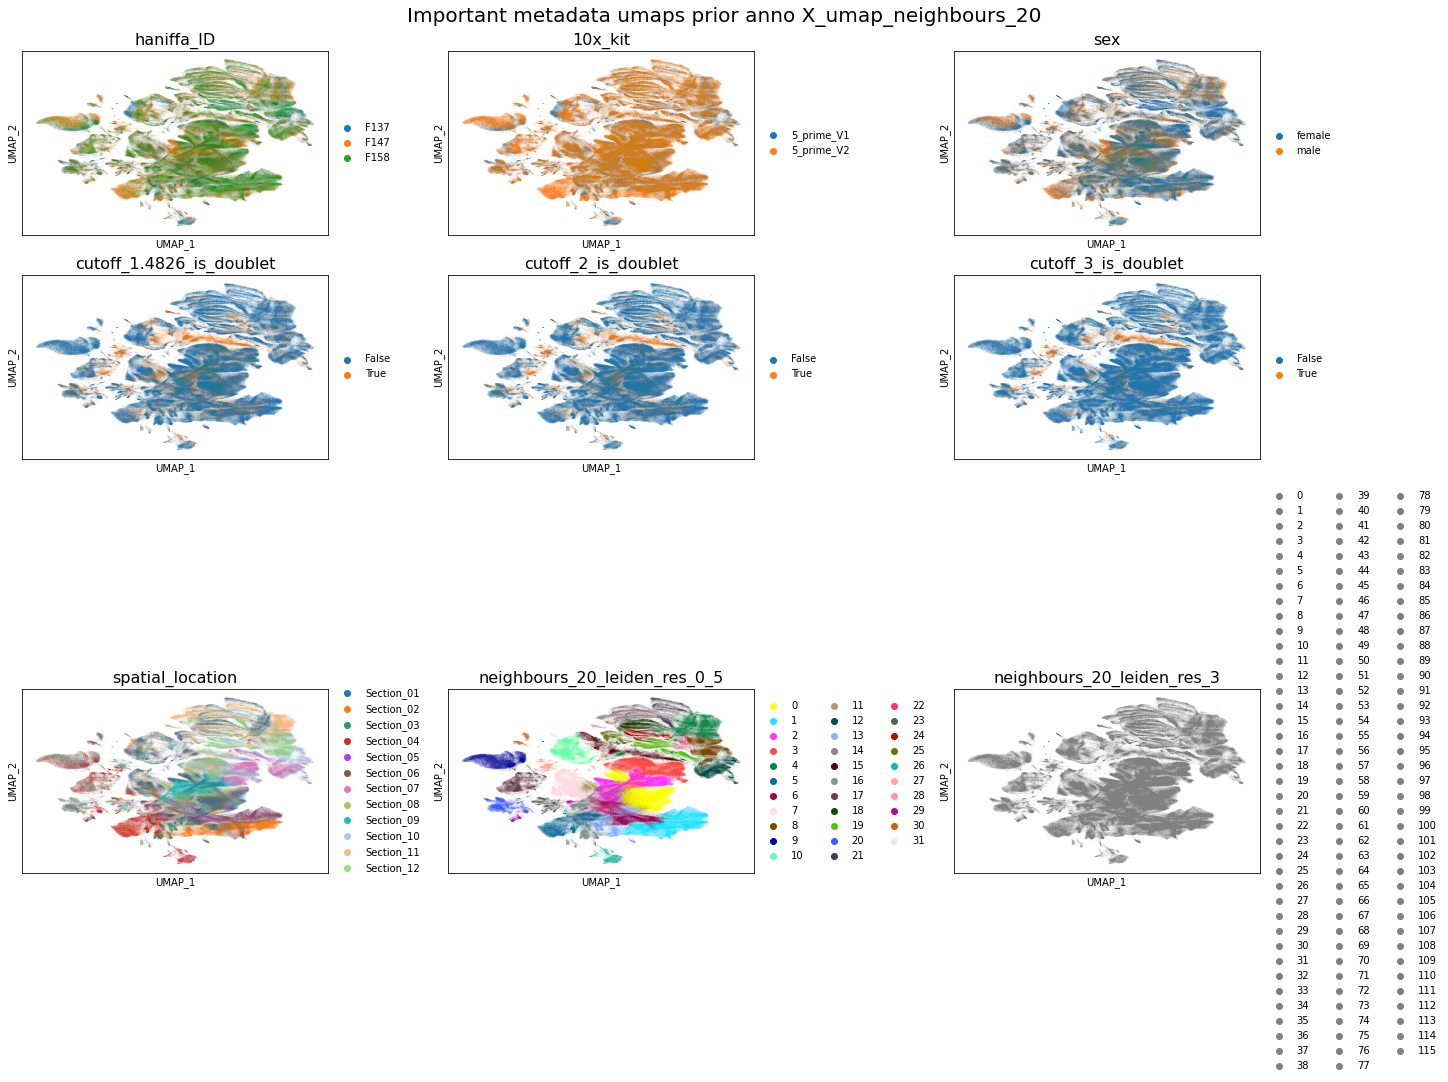

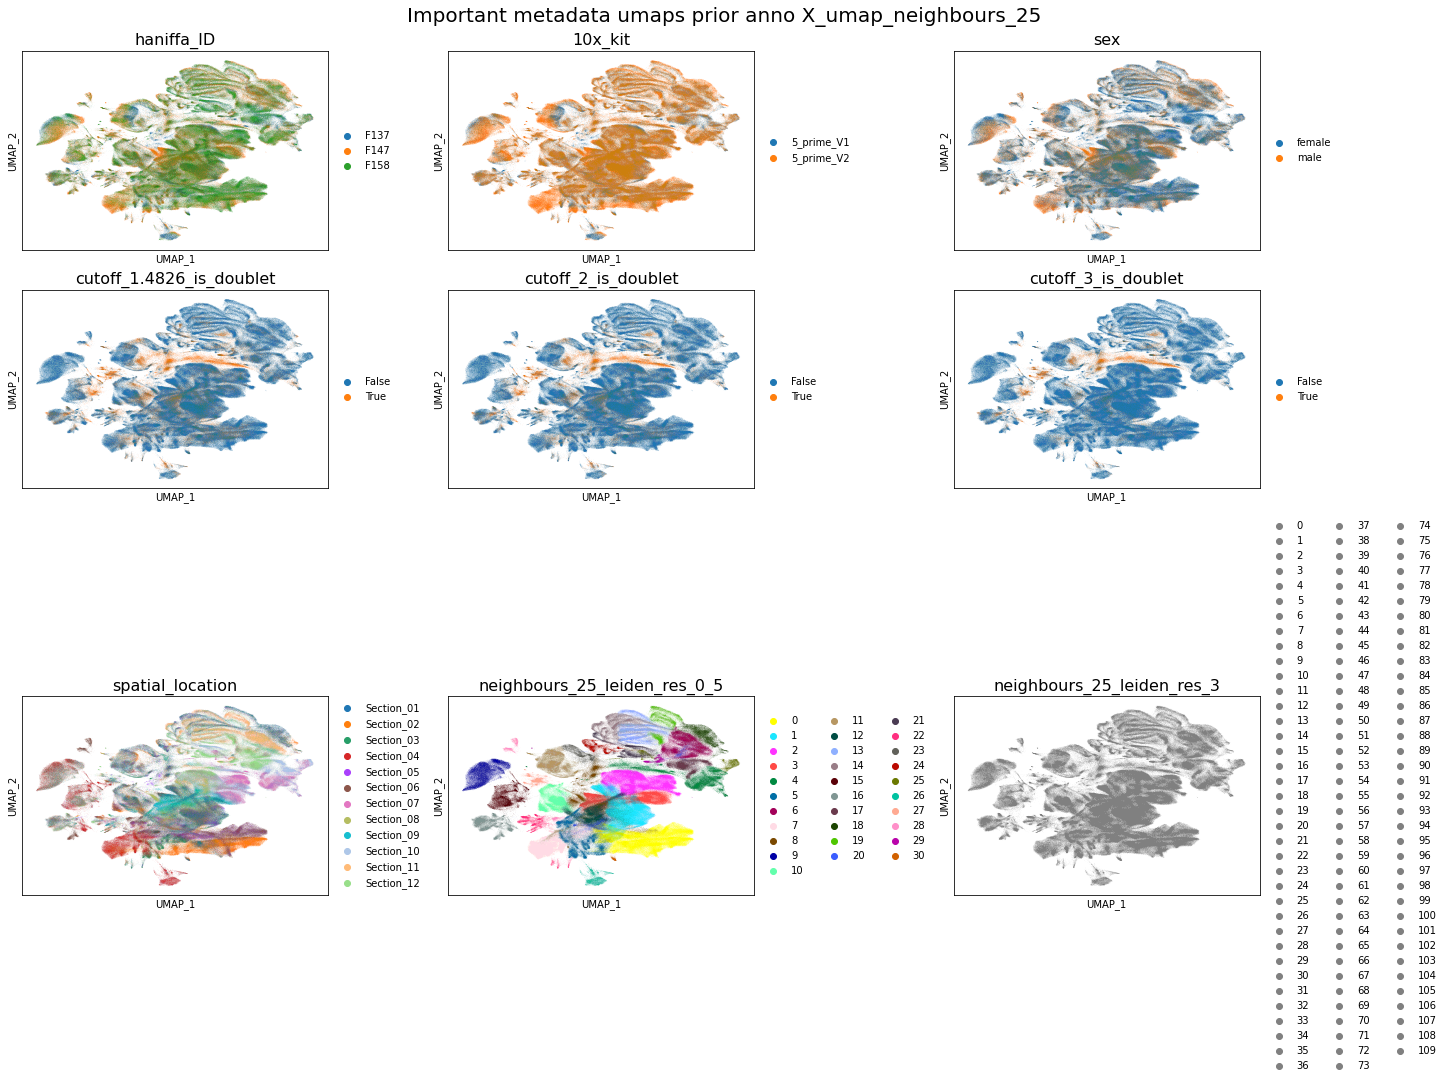

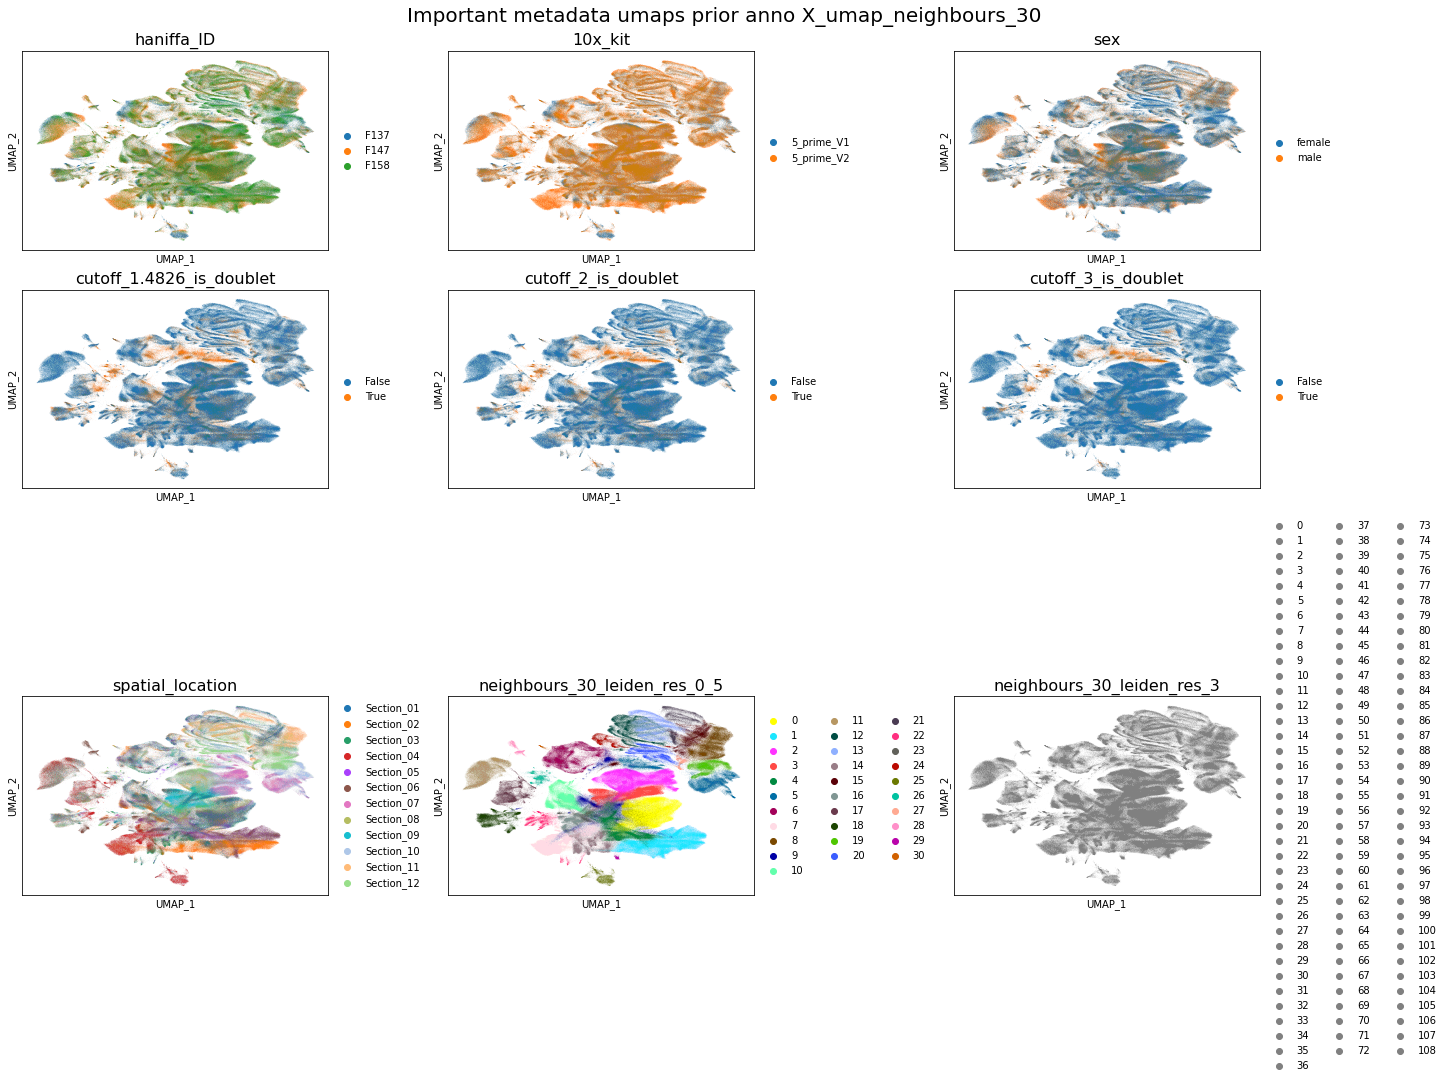

In [7]:
for neighbourhood in neighbourhoods:

    basis = neighbourhood
    
    fig = plt.figure(constrained_layout=True, figsize=(20,15))
    
    basis_split = basis.split("_", 2)
    leiden_low = basis_split[2] + '_leiden_res_0_5'
    leiden_high = basis_split[2] + '_leiden_res_3'
    
    ax1 = plt.subplot(3,3,1)
    color = 'haniffa_ID'
    sc.pl.embedding(adata, basis = basis, ax=ax1, show=False, title='', color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax2 = plt.subplot(3,3,2) 
    color = '10x_kit'
    sc.pl.embedding(adata, basis = basis, ax=ax2, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax3 = plt.subplot(3,3,3)
    color = 'sex'
    sc.pl.embedding(adata, basis = basis, ax=ax3, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax4 = plt.subplot(3,3,4)
    color = 'cutoff_1.4826_is_doublet'
    sc.pl.embedding(adata, basis = basis, ax=ax4, show=False, title='', color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax5 = plt.subplot(3,3,5) 
    color = 'cutoff_2_is_doublet'
    sc.pl.embedding(adata, basis = basis, ax=ax5, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax6 = plt.subplot(3,3,6)
    color = 'cutoff_3_is_doublet'
    sc.pl.embedding(adata, basis = basis, ax=ax6, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax7 = plt.subplot(3,3,7)
    color = 'spatial_location'
    sc.pl.embedding(adata, basis = basis, ax=ax7, show=False, title='', color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax8 = plt.subplot(3,3,8) 
    color = leiden_low
    sc.pl.embedding(adata, basis = basis, ax=ax8, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    ax9 = plt.subplot(3,3,9)
    color = leiden_high
    sc.pl.embedding(adata, basis = basis, ax=ax9, show=False, color = color)
    plt.xlabel('UMAP_1')
    plt.ylabel('UMAP_2')
    plt.title(color, fontsize=16)
    
    
    
    fig.suptitle('Important metadata umaps prior anno ' + neighbourhood, fontsize=20)
    fig.set_constrained_layout_pads(w_pad=4 / 72, h_pad=4 / 72, hspace=0.2, wspace=0.15)
    fig.savefig(umap_save_dir + 'Important_metadata_maps_pior_anno' + neighbourhood + '.png', bbox_inches='tight', dpi=300)
    plt.show()

/opt/conda/envs/Python_env_Hlab/lib/python3.9/site-packages/pandas/plotting/_matplotlib/core.py:386: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig = self.plt.figure(figsize=self.figsize)


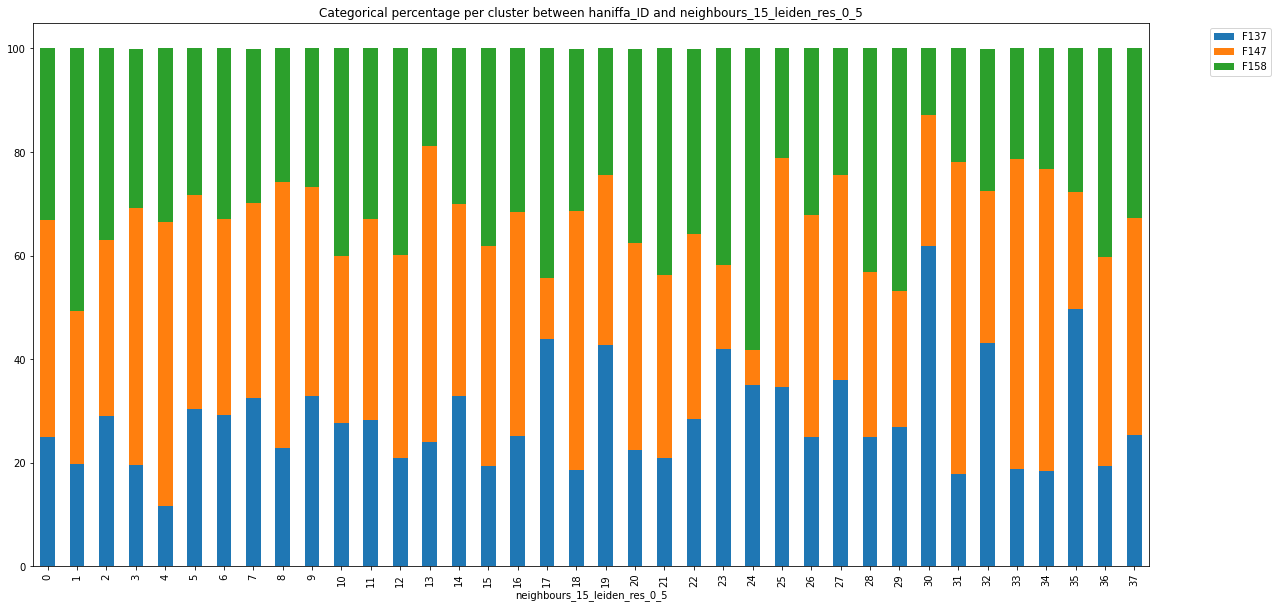

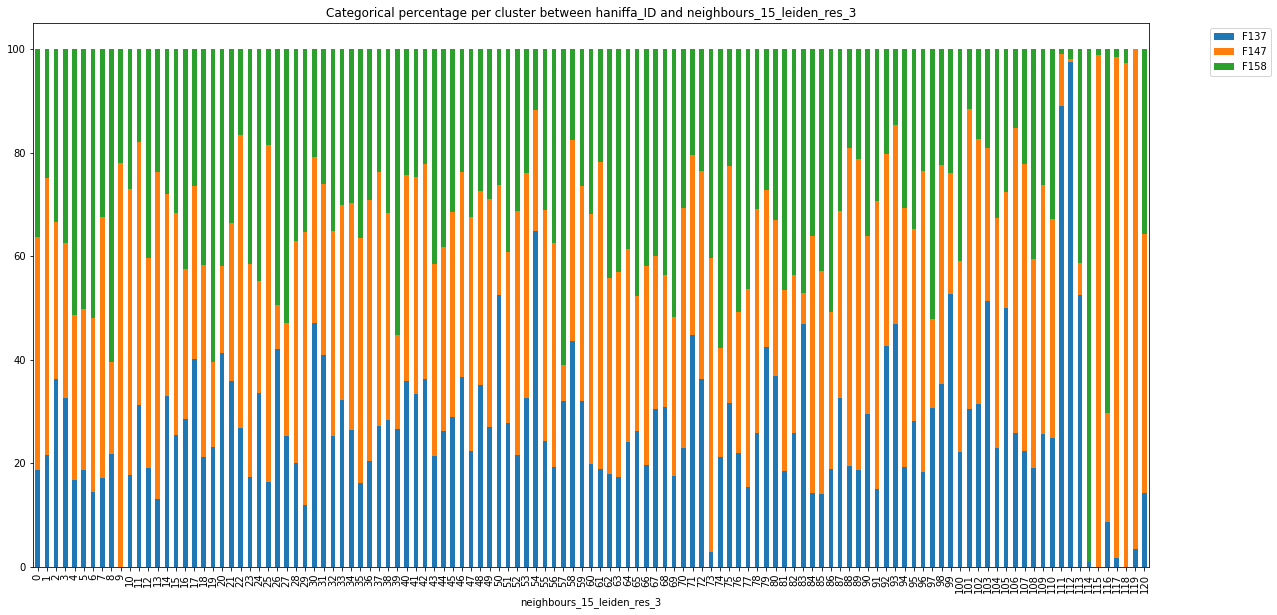

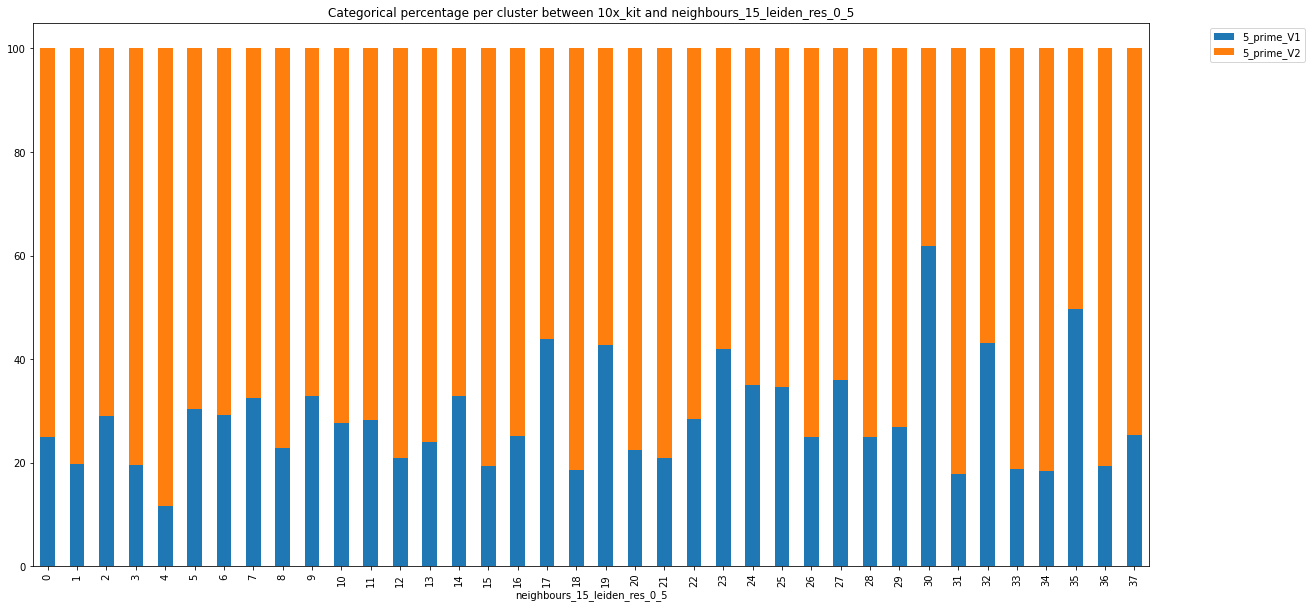

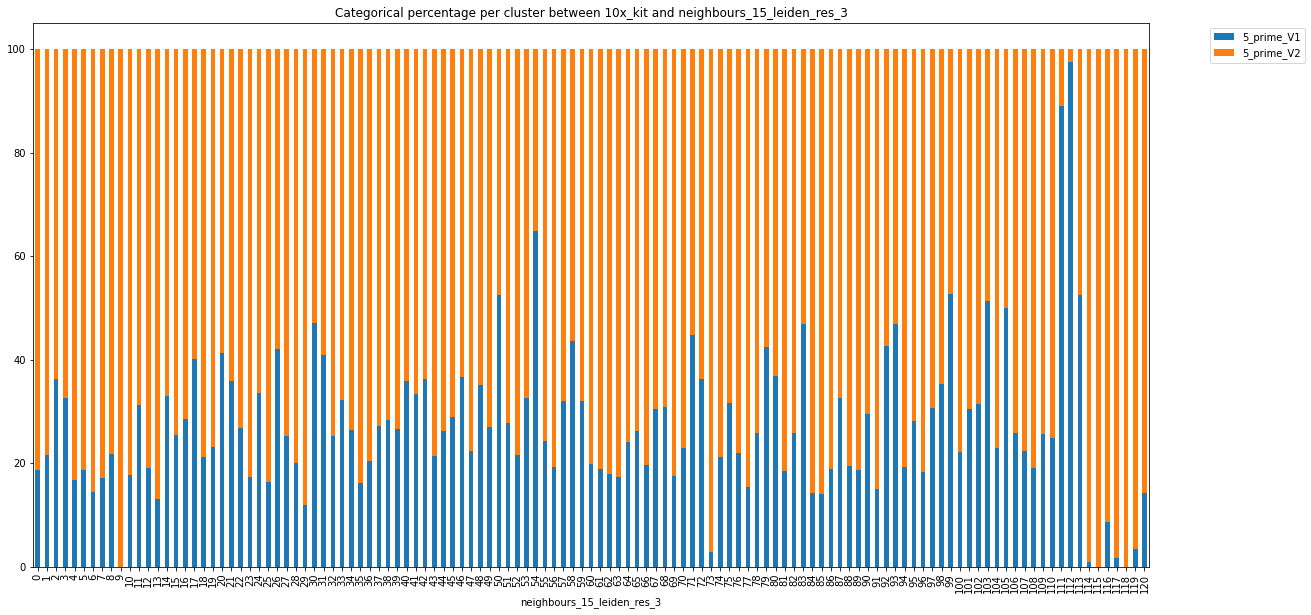

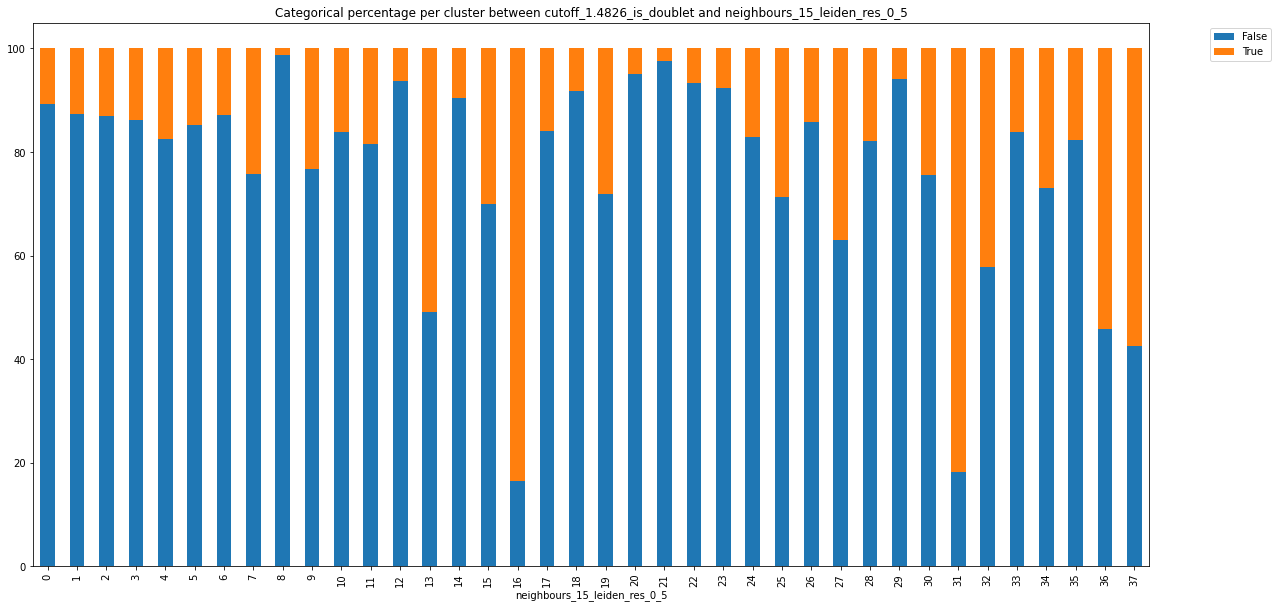

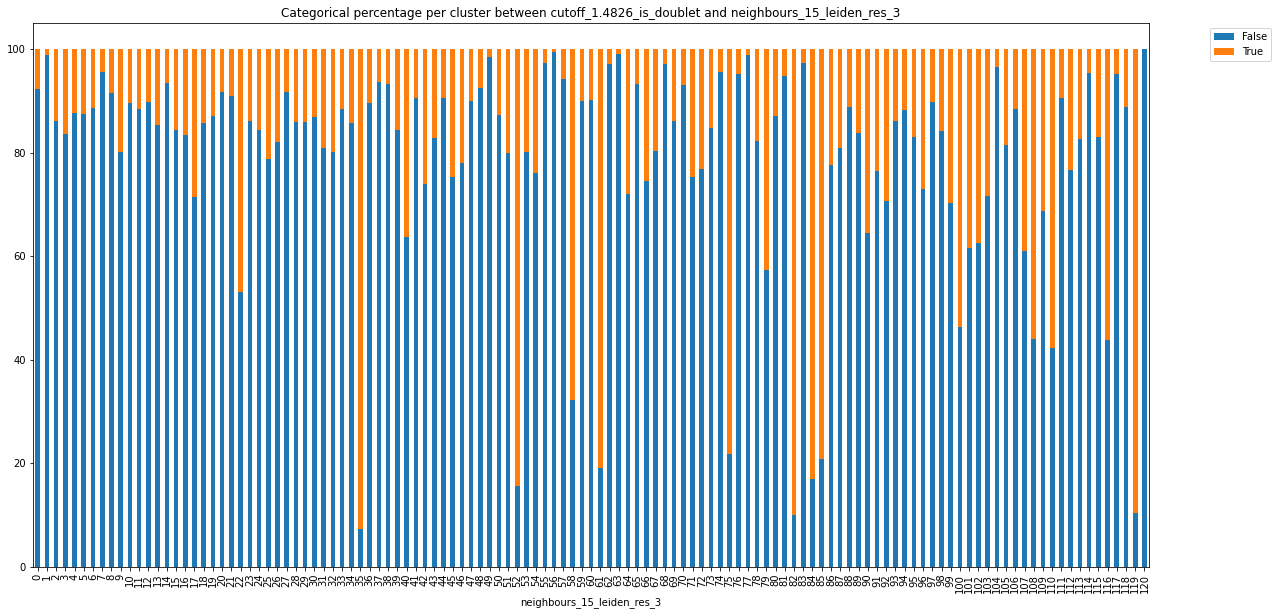

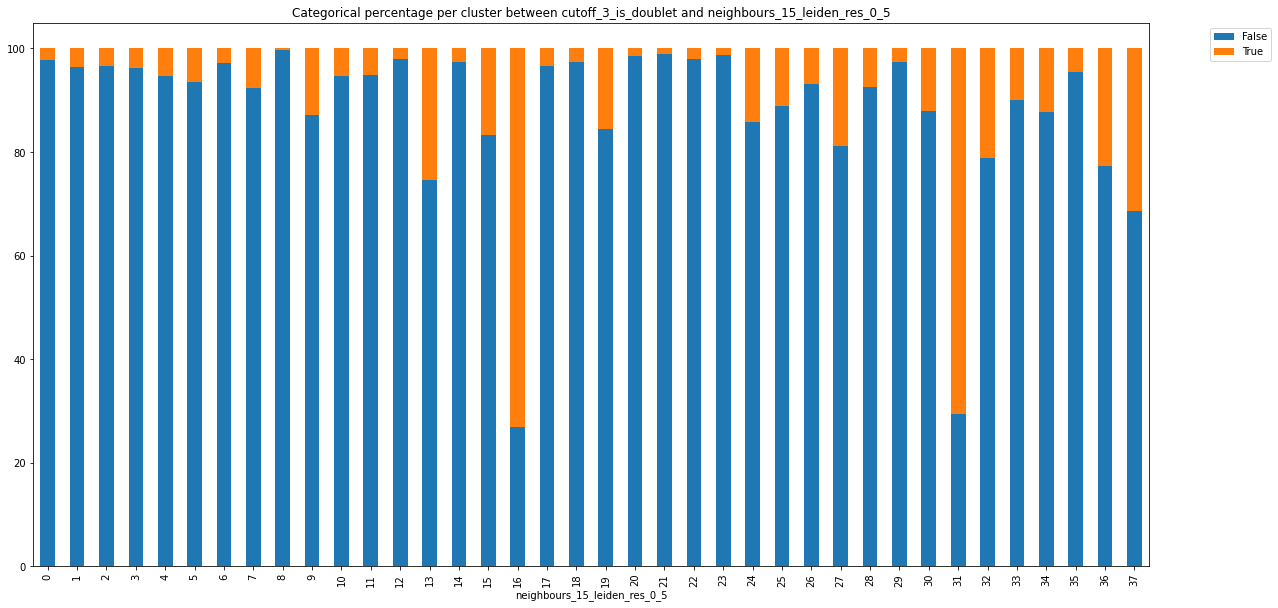

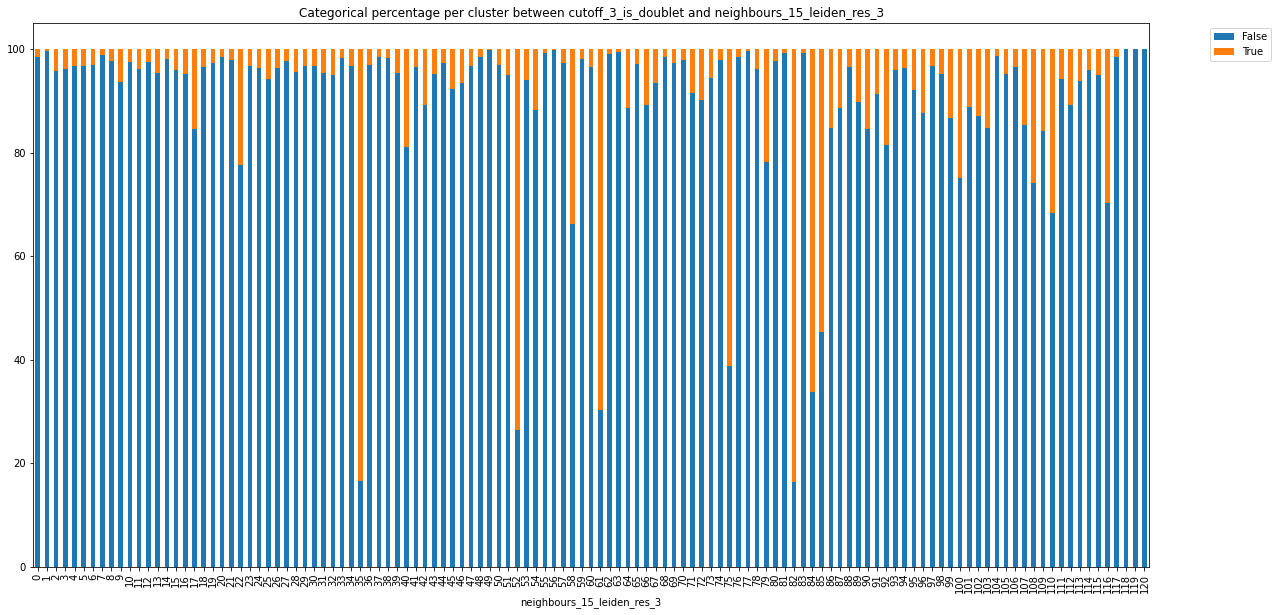

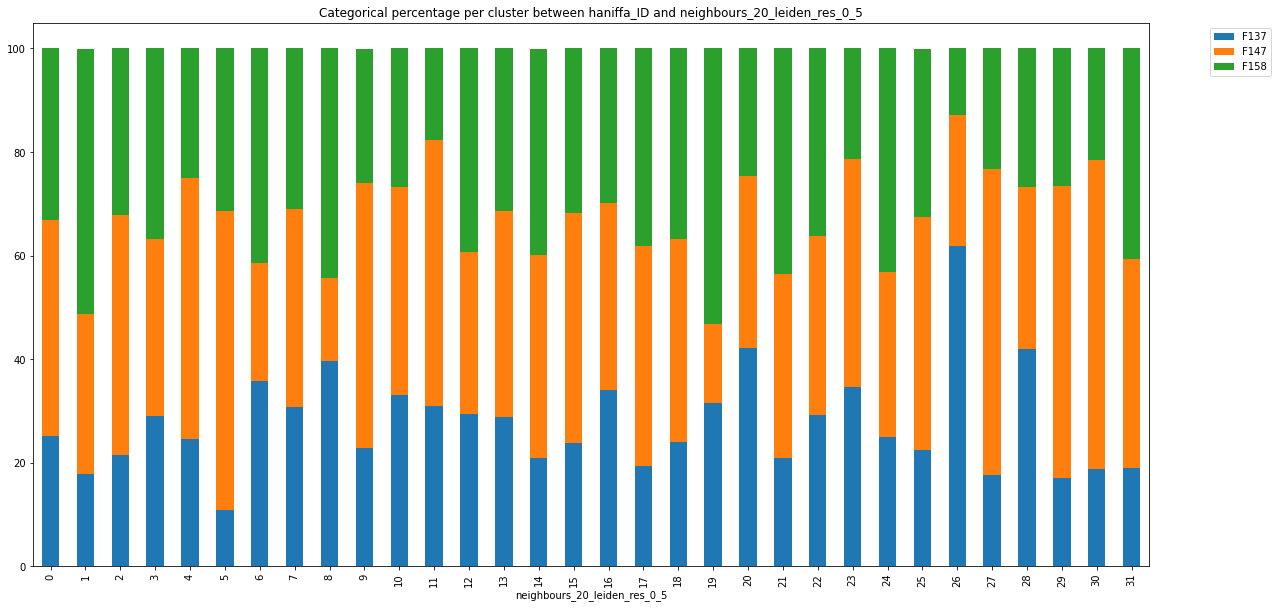

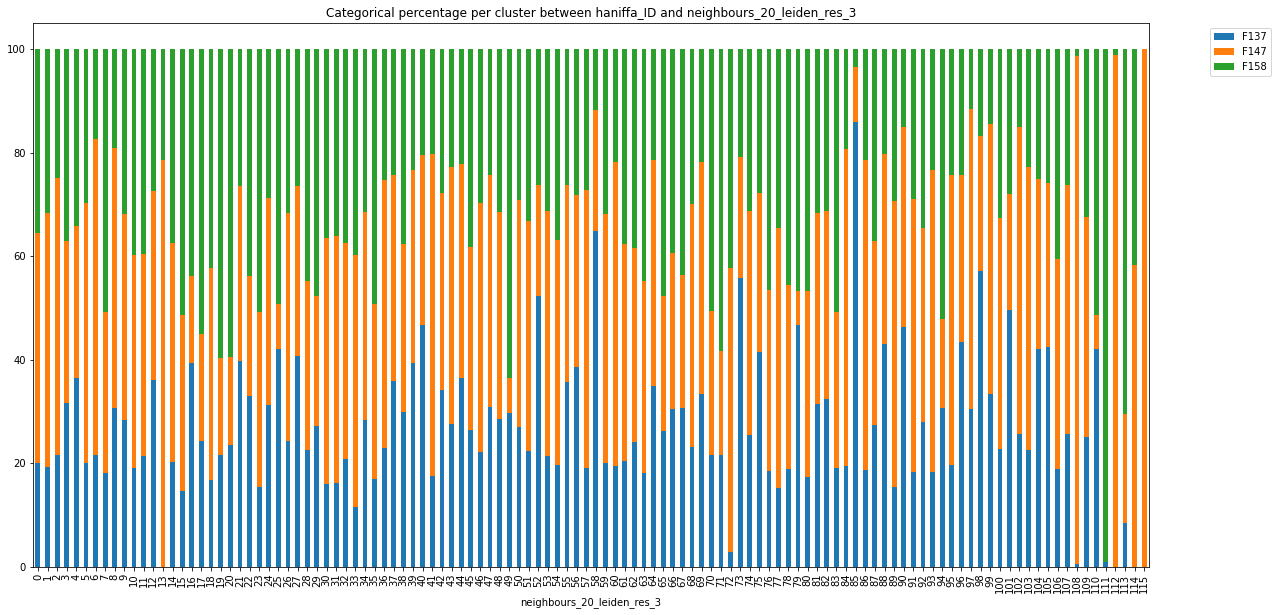

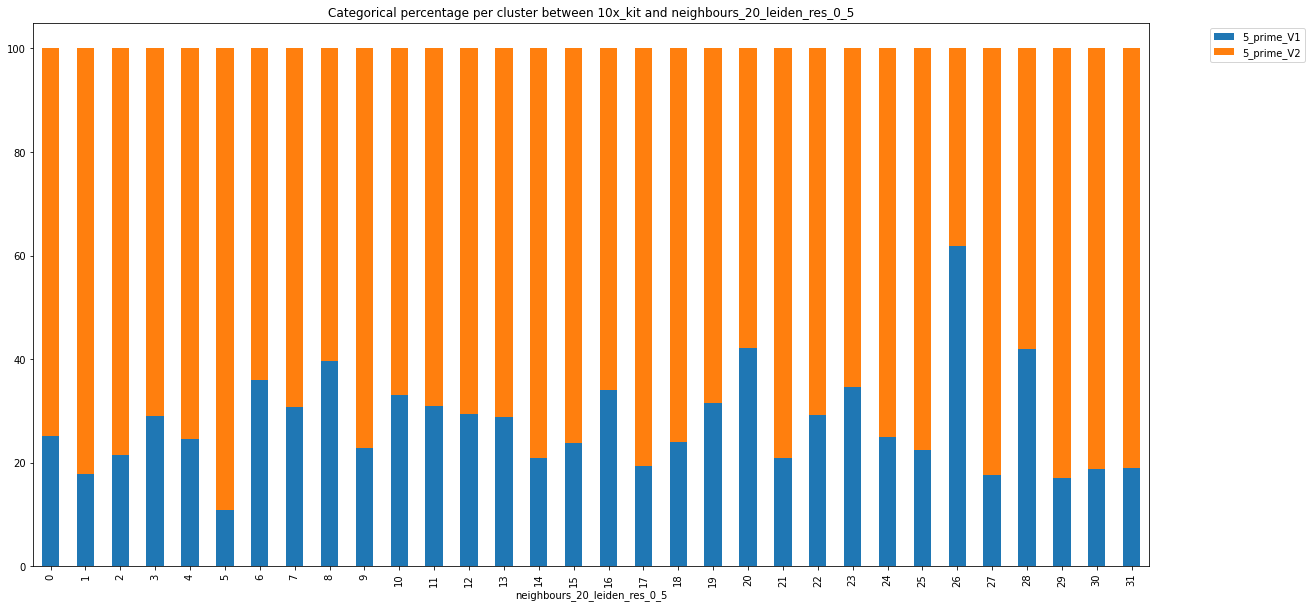

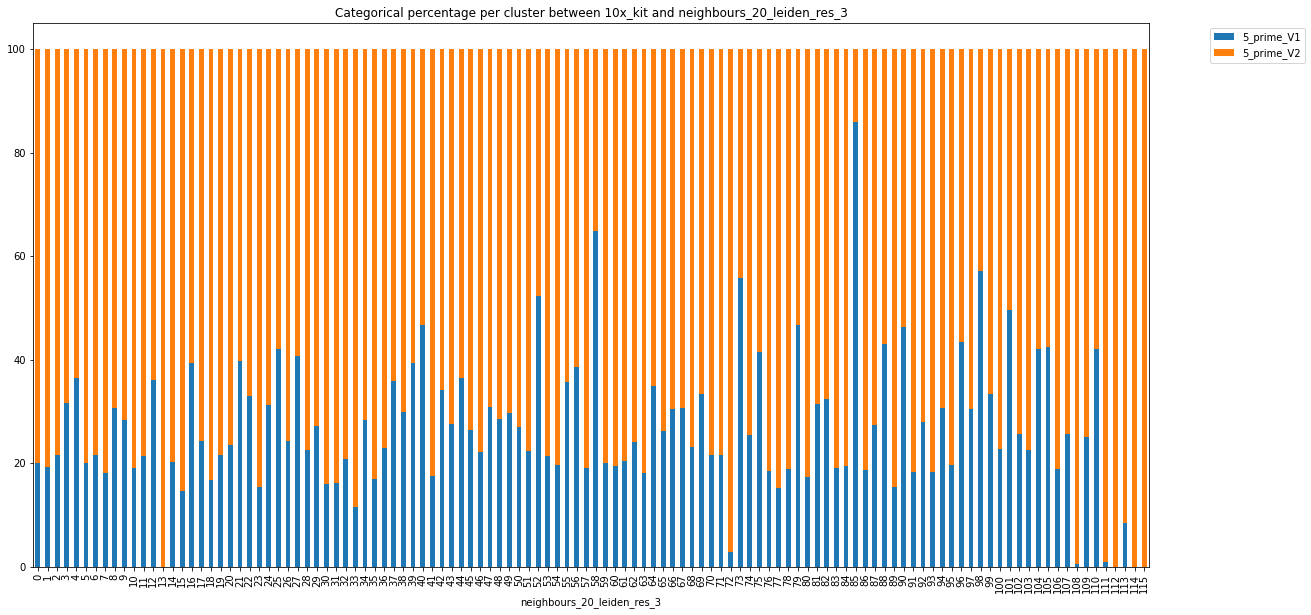

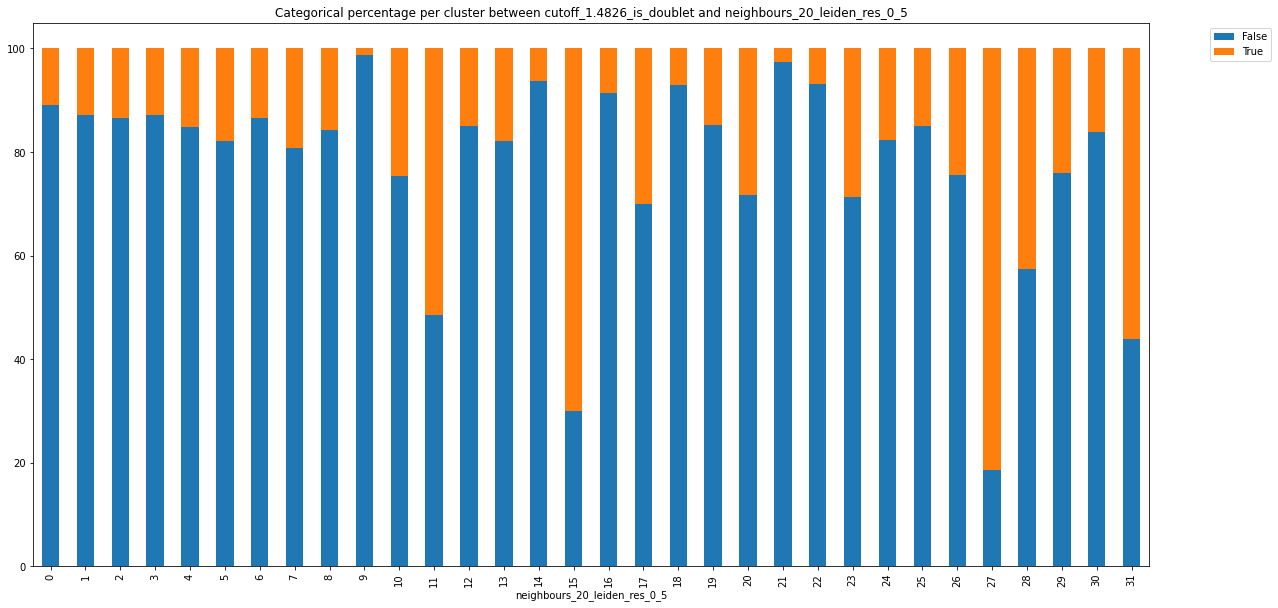

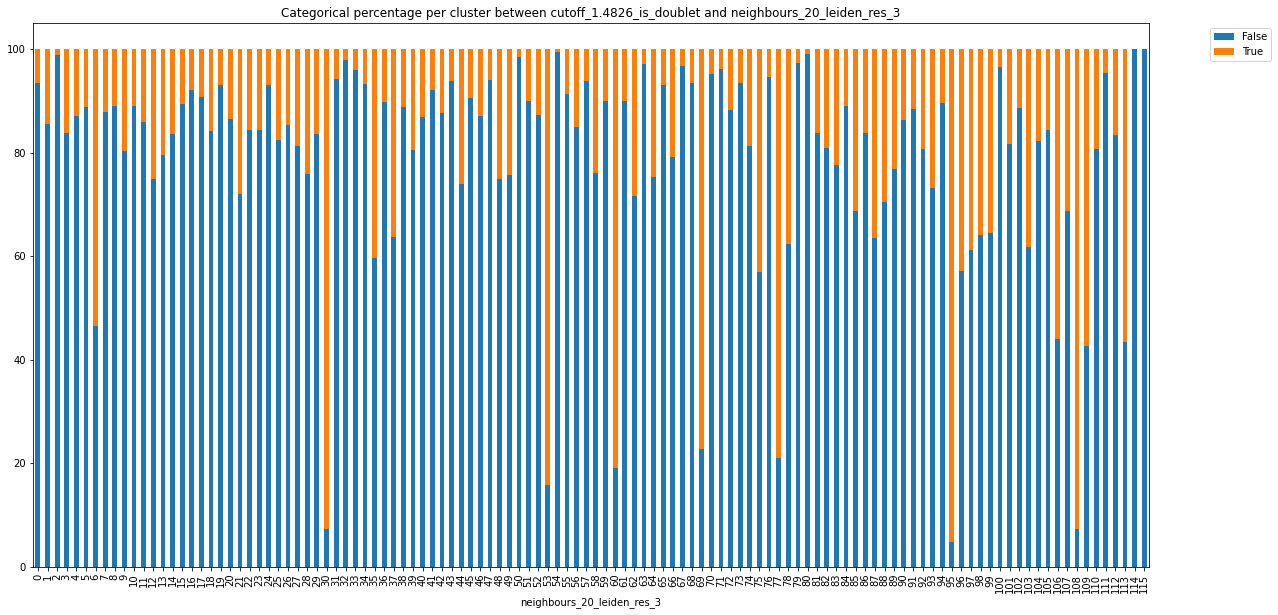

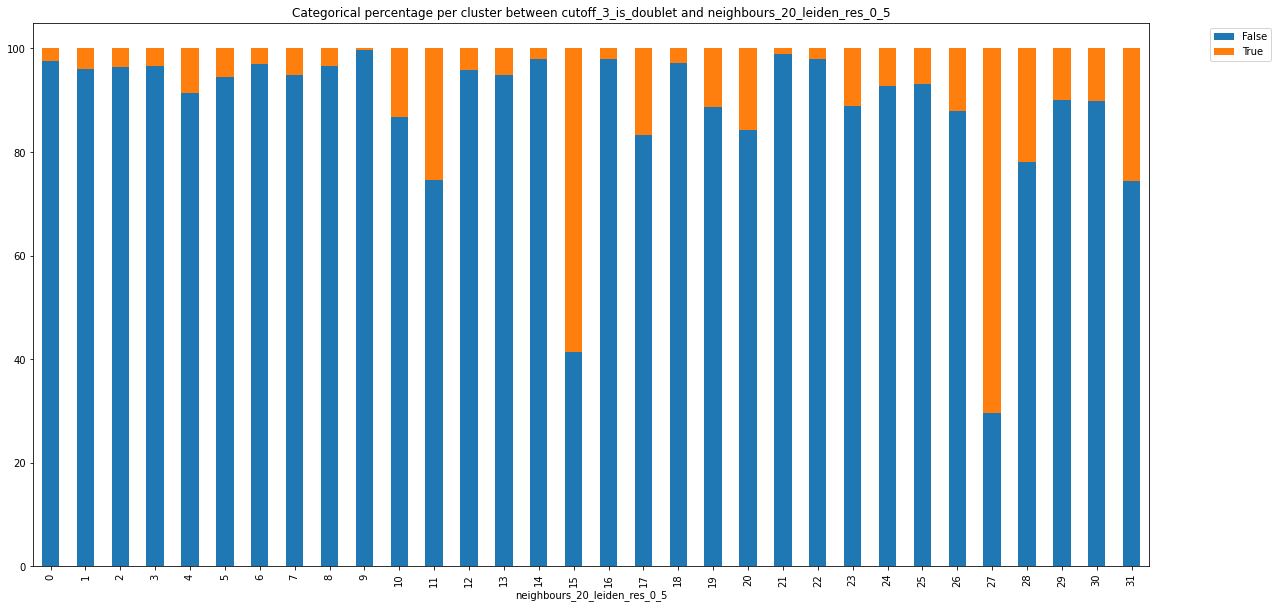

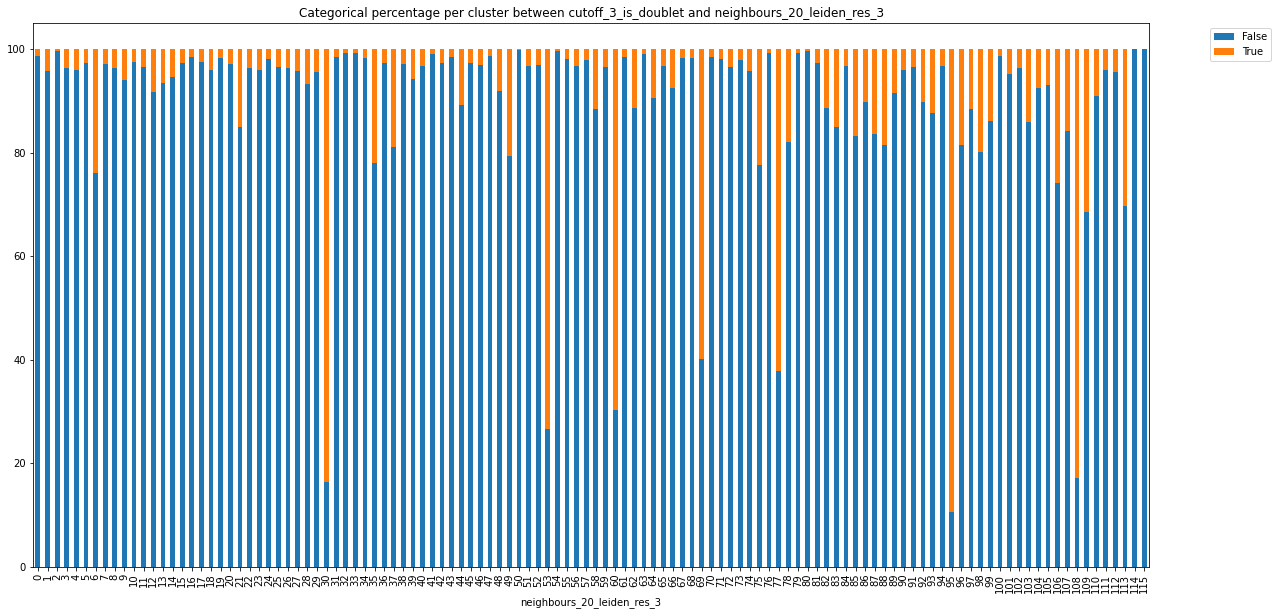

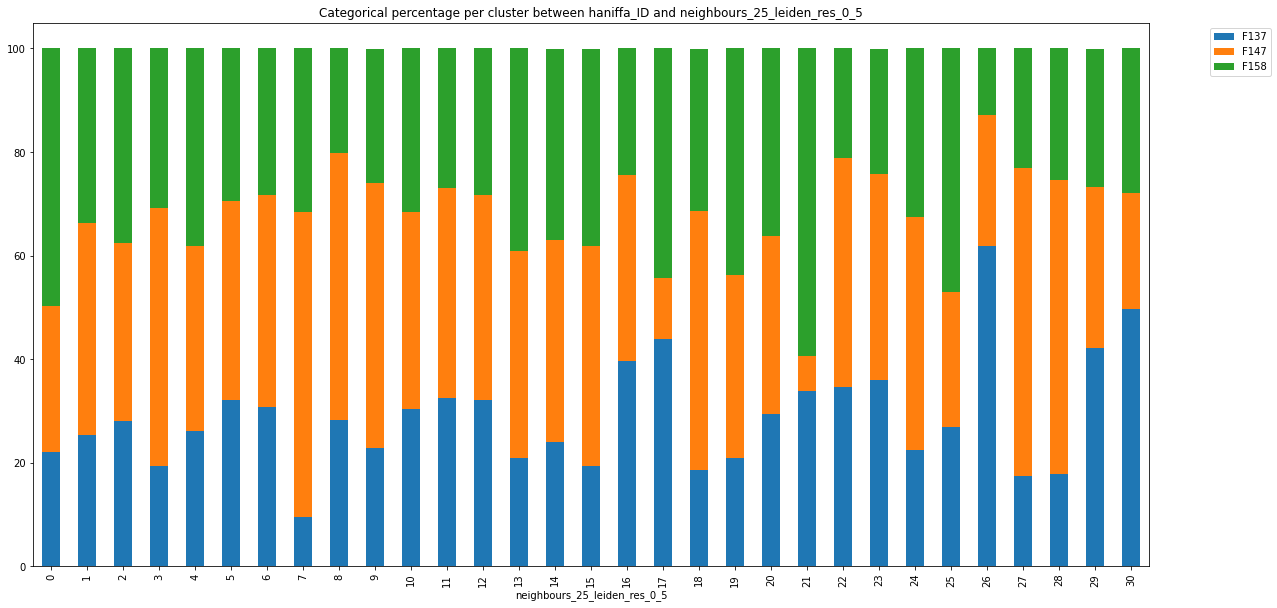

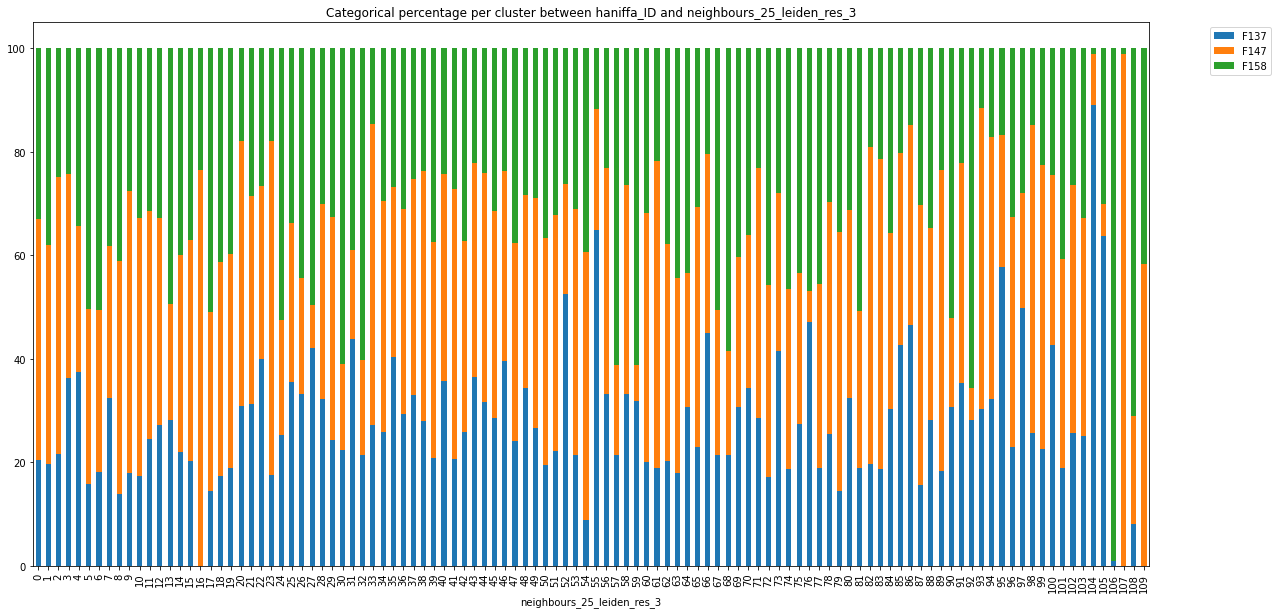

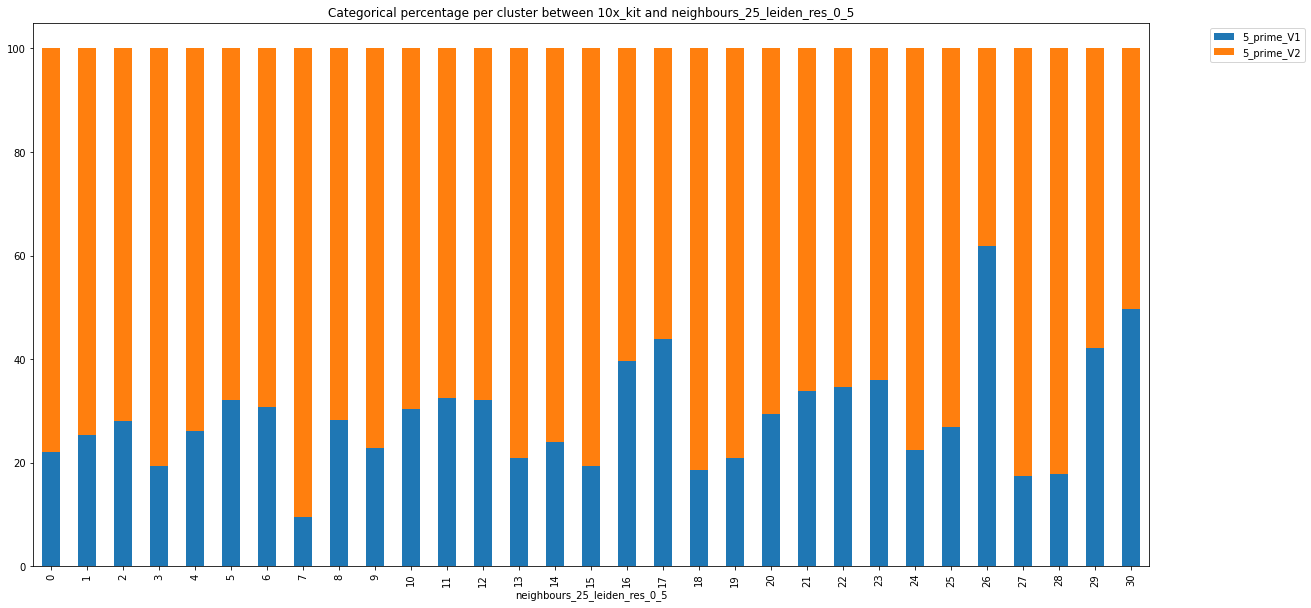

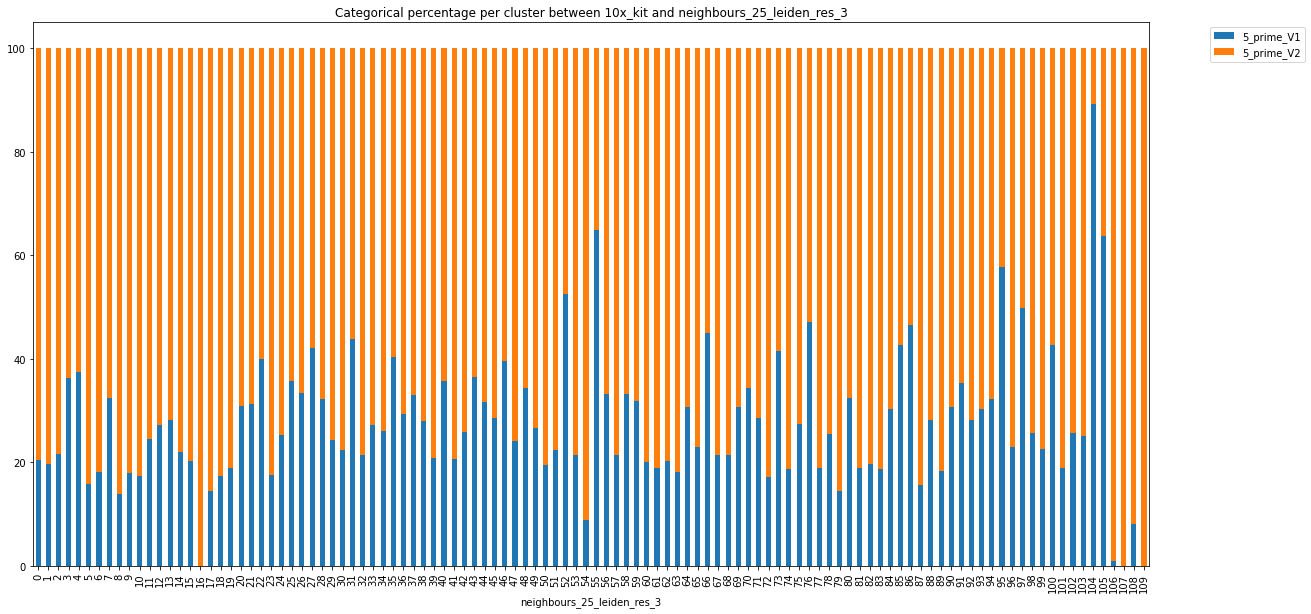

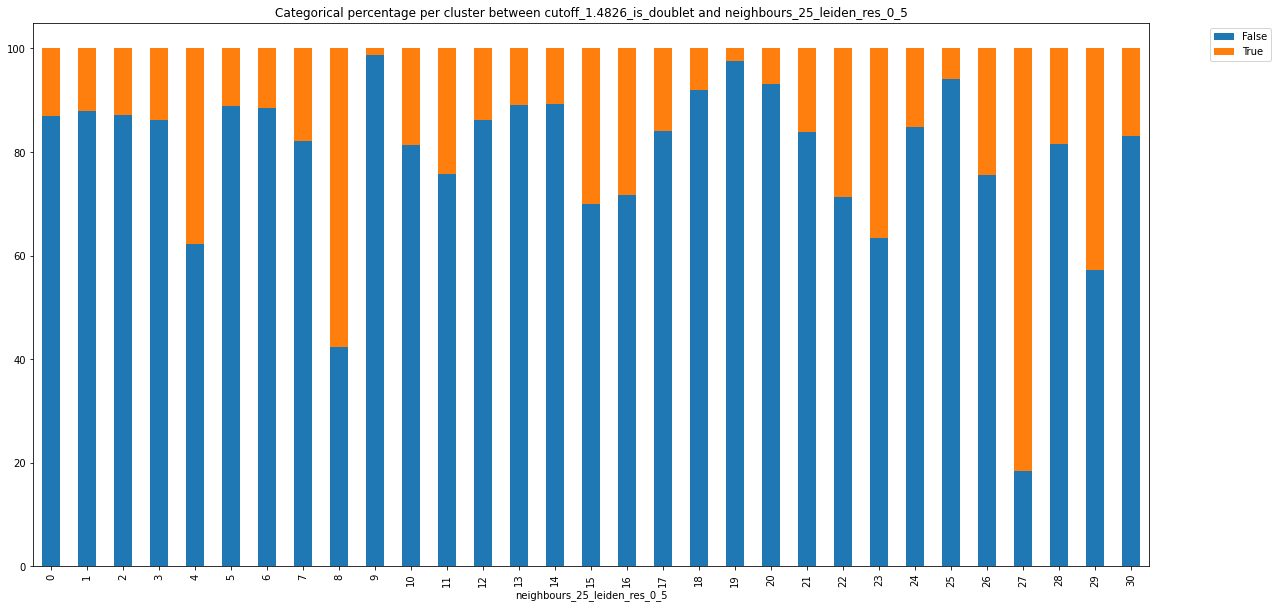

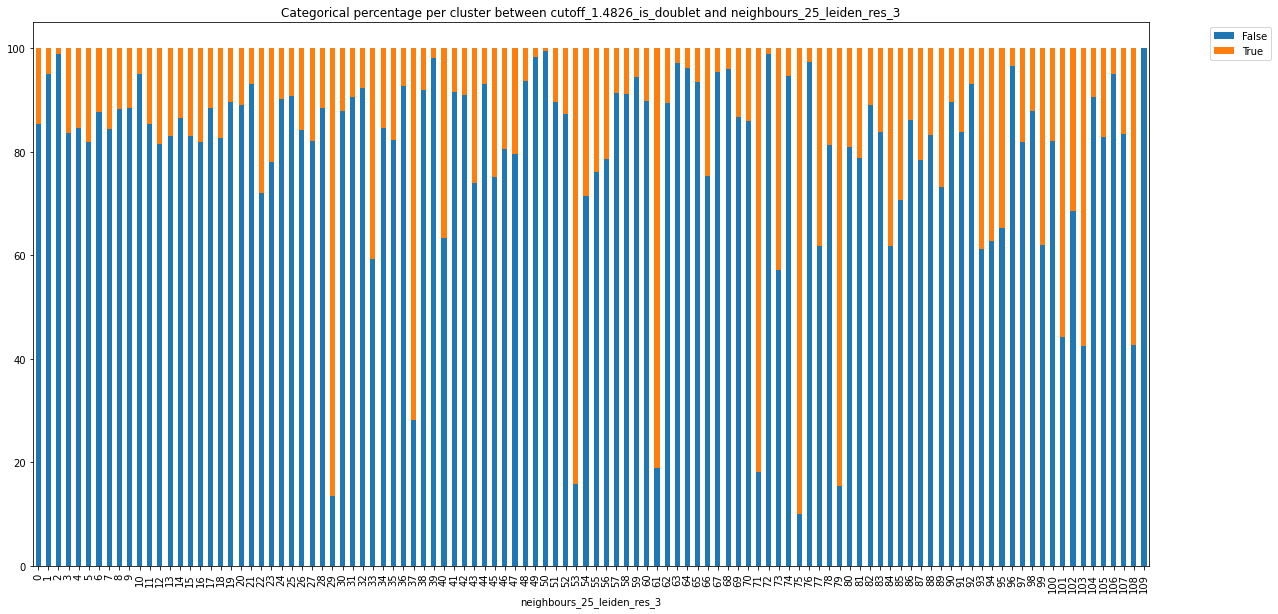

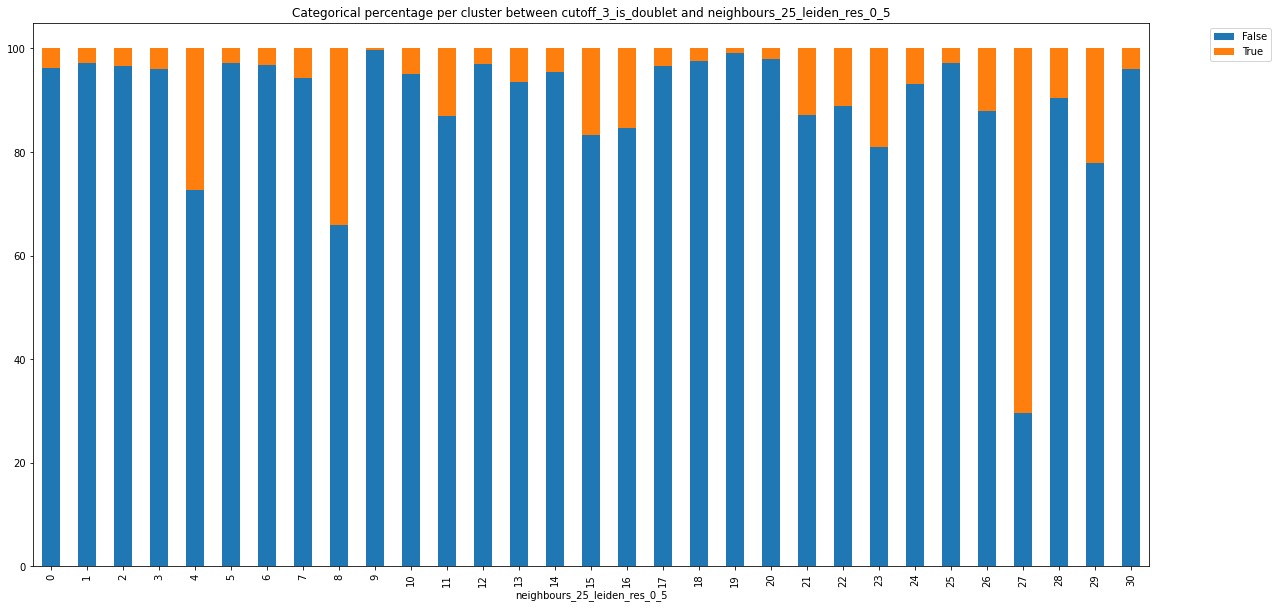

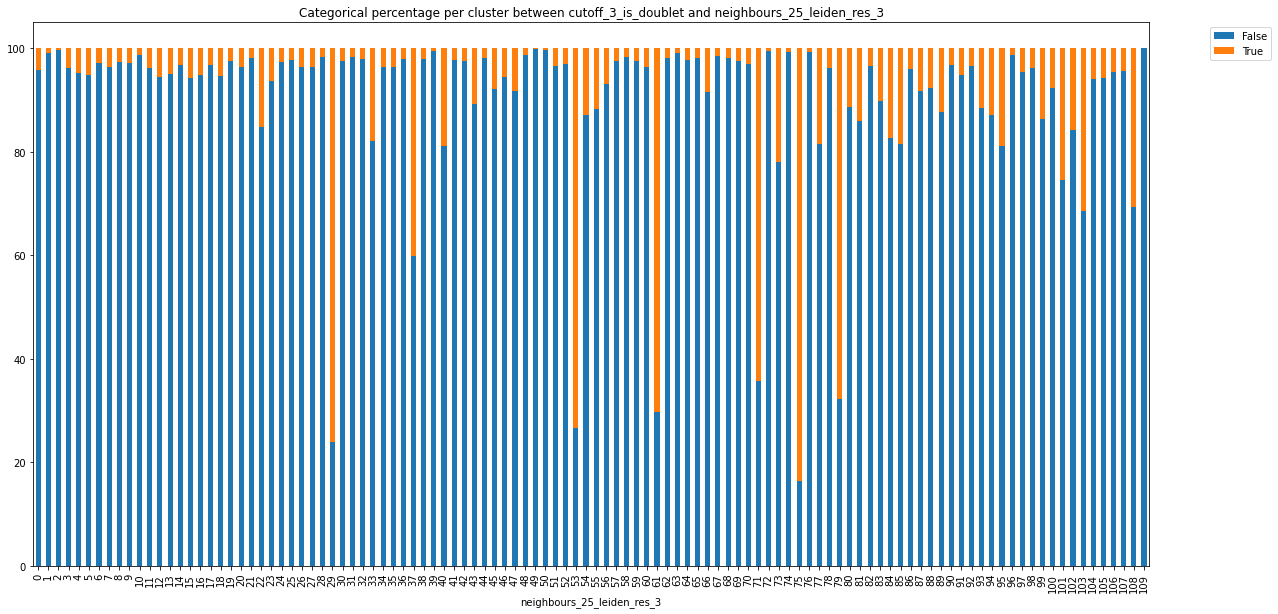

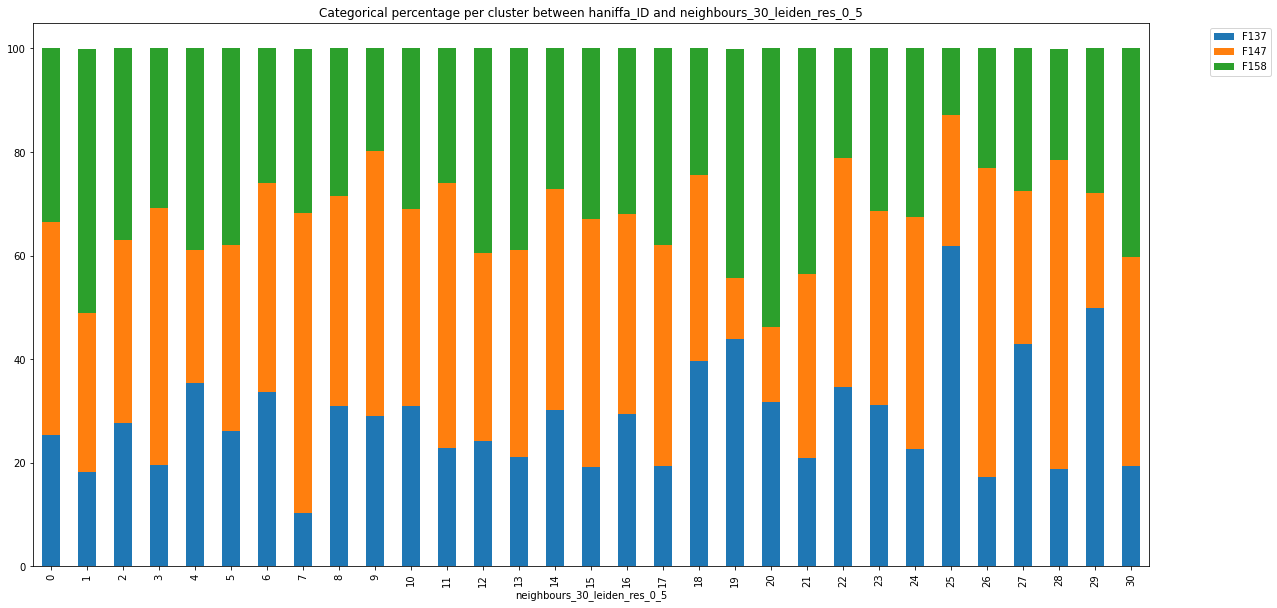

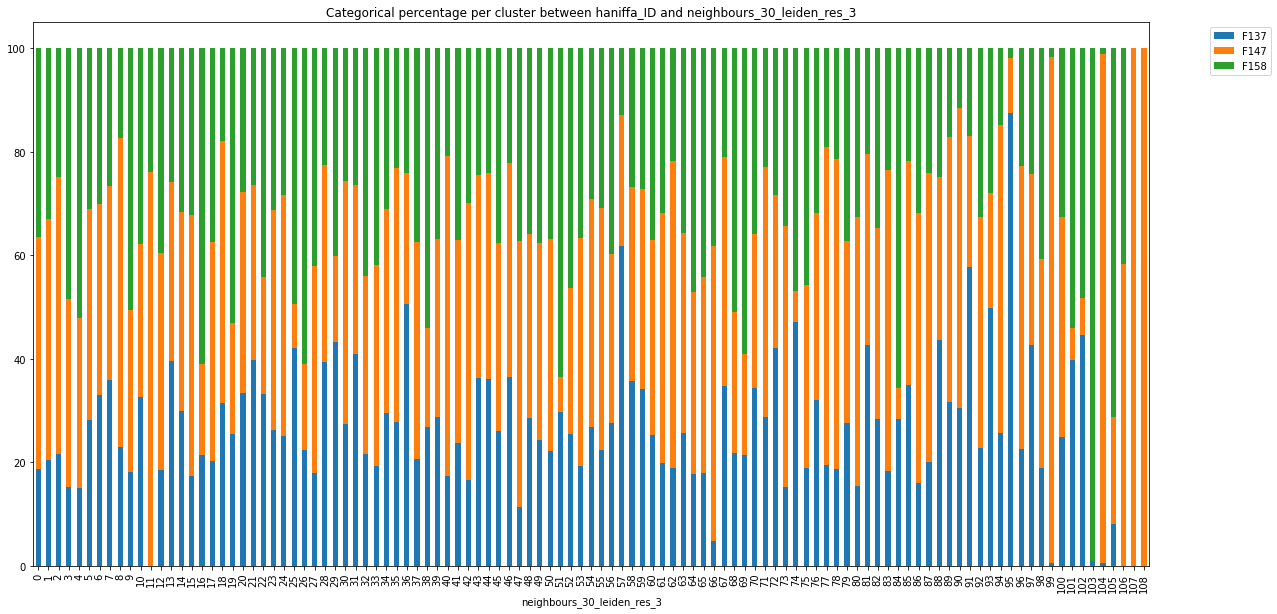

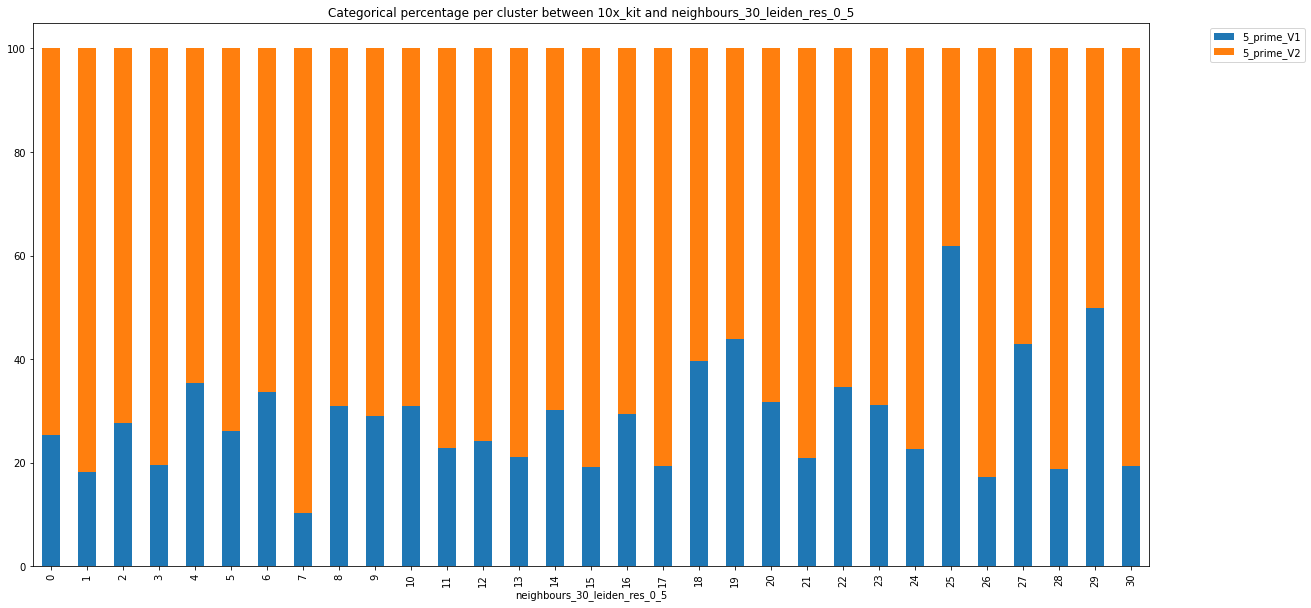

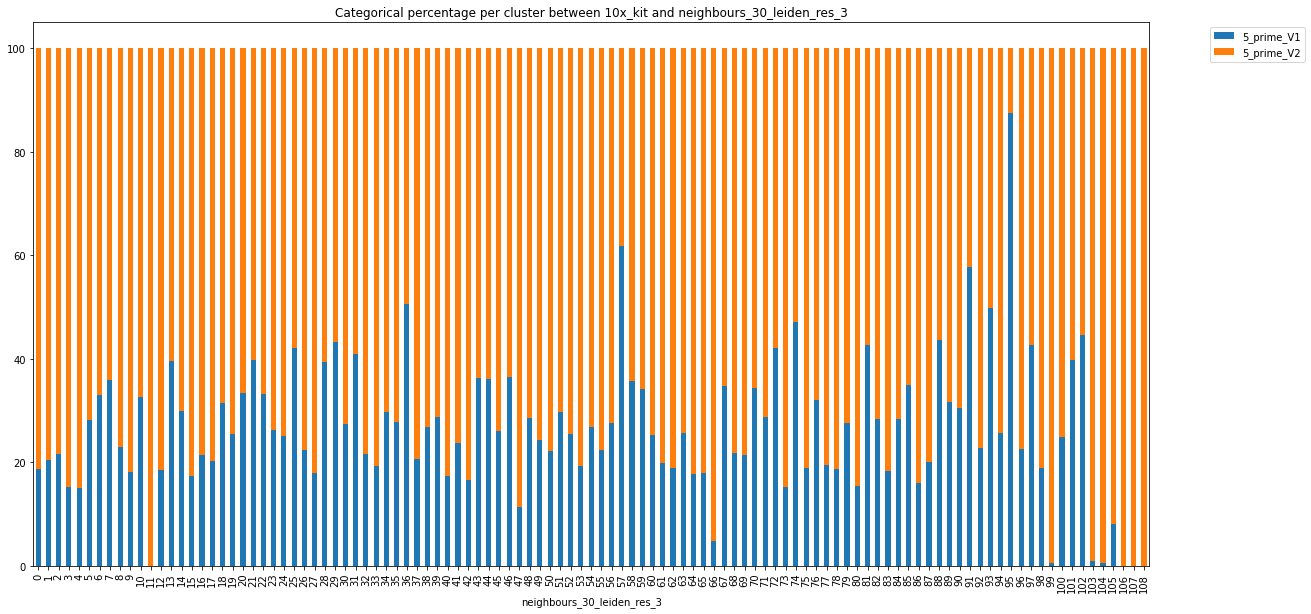

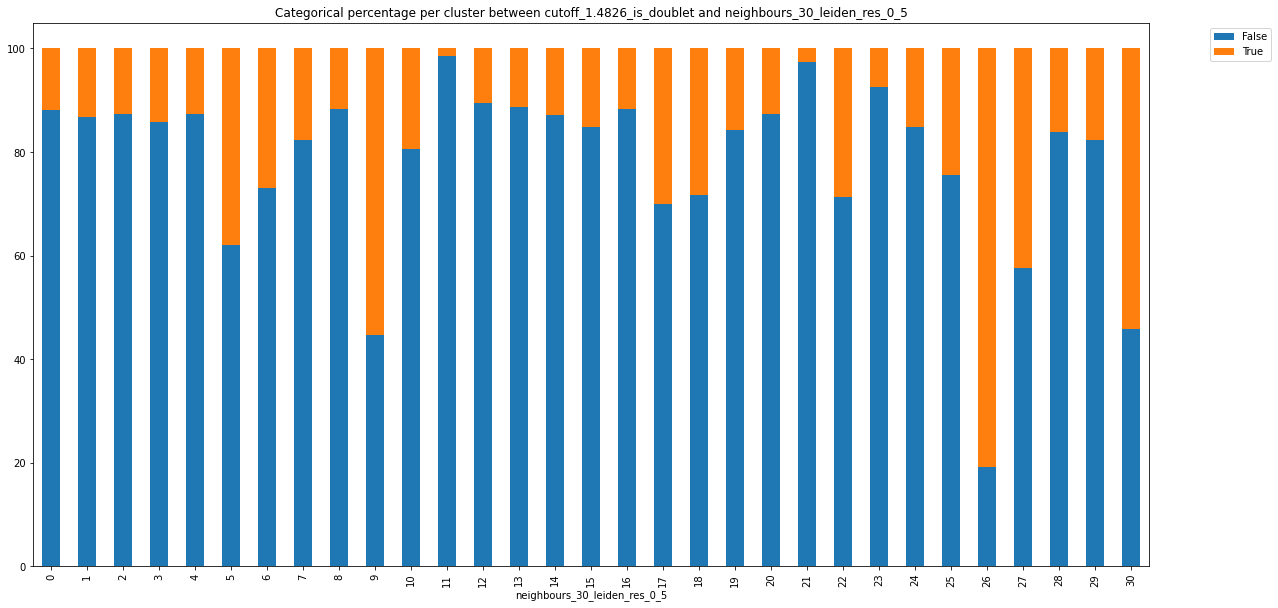

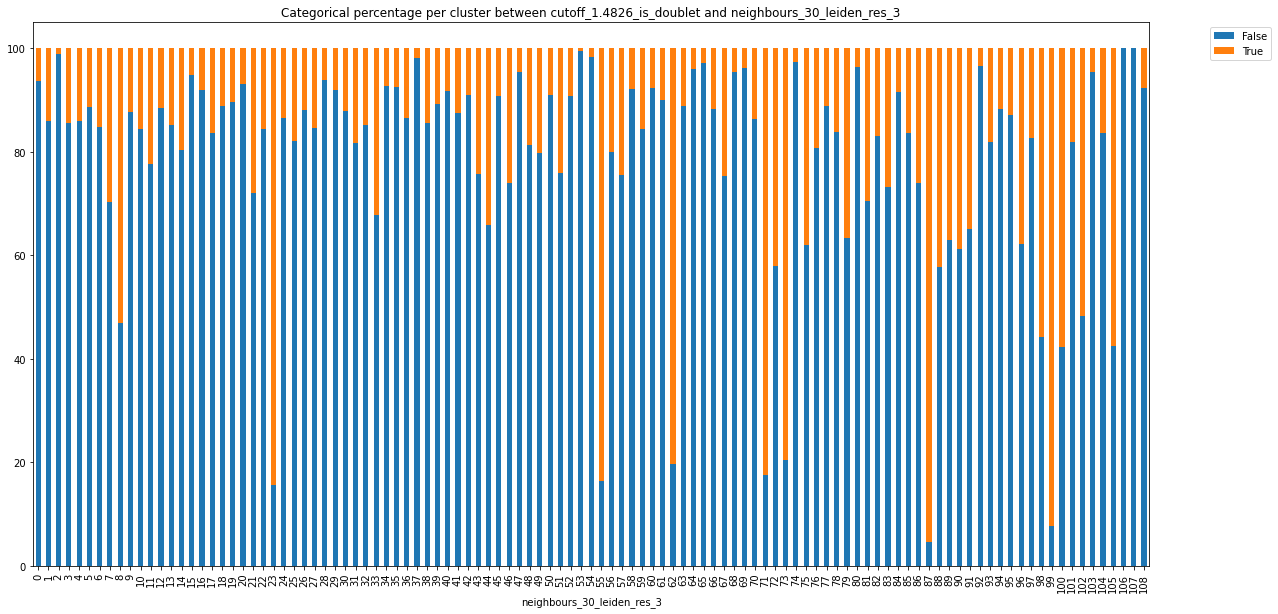

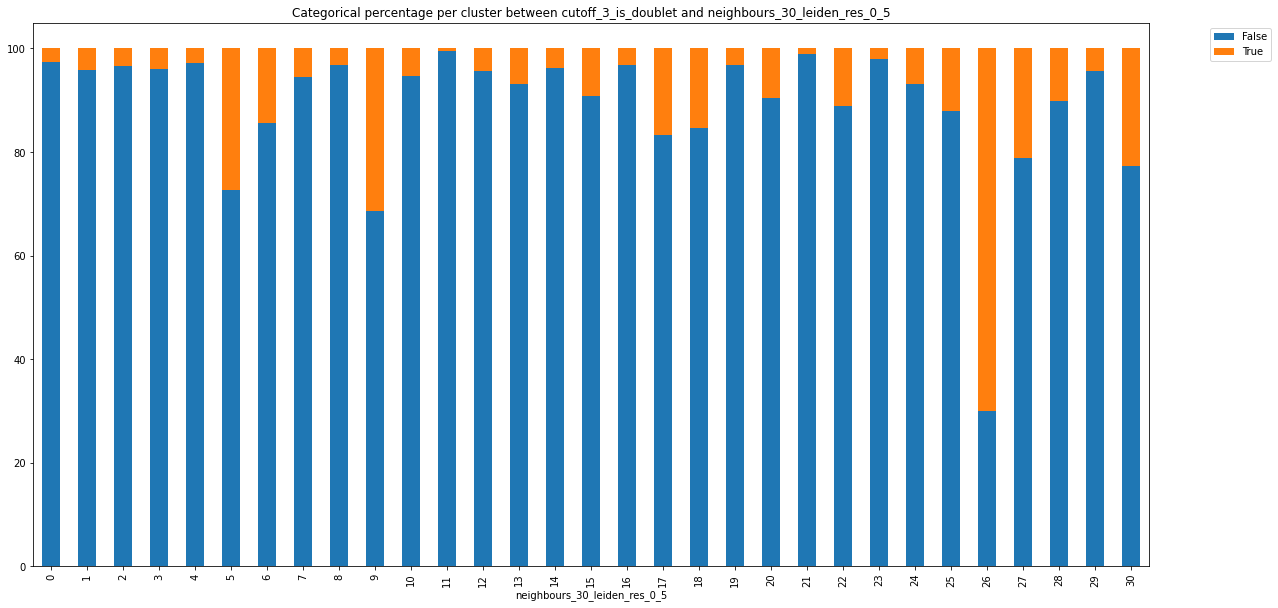

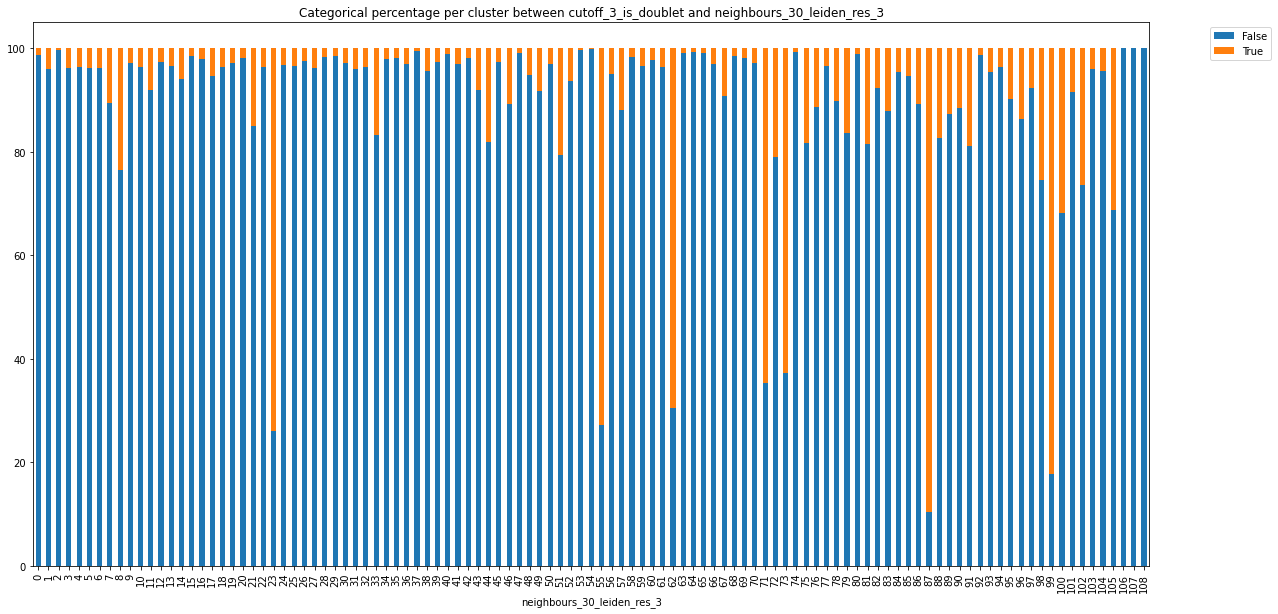

In [8]:
for neighbourhood in neighbourhoods:

    basis = neighbourhood
    
    basis_split = basis.split("_", 2)
    leiden_low = basis_split[2] + '_leiden_res_0_5'
    leiden_high = basis_split[2] + '_leiden_res_3'
    
    table_dict = {
    '1' : ['haniffa_ID',leiden_low],
    '2' : ['haniffa_ID',leiden_high],
    '3' : ['10x_kit',leiden_low],
    '4' : ['10x_kit',leiden_high],
    '5' : ['cutoff_1.4826_is_doublet',leiden_low],
    '6' : ['cutoff_1.4826_is_doublet',leiden_high],
    '7' : ['cutoff_3_is_doublet',leiden_low],
    '8' : ['cutoff_3_is_doublet',leiden_high],
    }
    
    for num in range(1,9):
        cat1 = table_dict[str(num)][0]
        cat2 = table_dict[str(num)][1]
        cat1_labels = adata.obs[cat1]
        cat2_labels = adata.obs[cat2]
        table = pd.crosstab(cat1_labels,cat2_labels)
        table.to_csv(braplot_save_dir + 'table_for_' + cat1 + '_against_' + cat2 + '.csv')
        percent_table = table
        percent_table = round((percent_table/percent_table.sum())*100,2)
        percent_table.to_csv(braplot_save_dir + 'percent_table_for_' + cat1 + '_against_' + cat2 + '.csv')
        percent_table.T.plot(kind='bar', stacked=True,title='Categorical percentage per cluster between ' + cat1 + ' and ' + cat2, figsize=(20,10))
        plt.legend(bbox_to_anchor=(1.05, 1))
        plt.savefig(braplot_save_dir + 'Barplot_showing_' + cat1 + '_against_' + cat2 + '.png')

# Score the neighbourhoods

- Scoring is done using Purity score, Homogeneity Score, Completeness Score, Normalised mututal information score and Shilouette global 
- For 15 NN, this will also be used for cross model evalusation / comparison

In [ ]:
for neighbourhood in neighbourhoods:

    basis = neighbourhood

    Scoring_table = pd.DataFrame(columns = ['Basis', 'meta_cat', 'Purity_Score', 'Homogeneity_Score', 'Completeness_Score', 'Normalized_mutual_info_Score','Sil_global_score'])
    
    cats = ['haniffa_ID','10x_kit']
    
    for cat in cats:
        confusion_matrix = pd.crosstab(adata.obs[leiden_low],adata.obs[cat])
        Purity_Score = ((confusion_matrix.max(axis = 1)).sum()) / confusion_matrix.sum().sum()
        Homogeneity_Score = homogeneity_score(adata.obs[cat], adata.obs[leiden_low])
        Completeness_Score = completeness_score(adata.obs[cat], adata.obs[leiden_low])
        Normalized_mutual_info_Score = normalized_mutual_info_score(adata.obs[cat], adata.obs[leiden_low])
        sil_global = silhouette_score(adata.obsm[neighbourhood], adata.obs[cat], metric='euclidean')
        
        Scoring_table.loc[len(Scoring_table)] = [neighbourhood,cat,Purity_Score,Homogeneity_Score,Completeness_Score,Normalized_mutual_info_Score,sil_global]
        
        # also do shilouette per sample for cats
        sil_samples = silhouette_samples(adata.obsm[neighbourhood], adata.obs[cat], metric='euclidean')
        savetxt(scoring_save_dir + 'sil_sample_scores_for_' + cat + '_on_' + neighbourhood + '.csv', sil_samples, delimiter=',')
        
    Scoring_table.to_csv(scoring_save_dir + 'Scoring_table_for_' + neighbourhood + '.csv')

***
### Dependencies
Here are some information about resources and import package versions used within this script

In [1]:
%load_ext watermark
%watermark -v -m -p numpy,pandas,scanpy,anndata,scvi,sklearn

Global seed set to 0


Python implementation: CPython
Python version       : 3.9.4
IPython version      : 7.31.1

numpy  : 1.20.3
pandas : 1.4.0
scanpy : 1.7.2
anndata: 0.7.6
scvi   : 0.6.8
sklearn: 1.0.2

Compiler    : GCC 9.3.0
OS          : Linux
Release     : 4.19.0-23-cloud-amd64
Machine     : x86_64
Processor   : 
CPU cores   : 32
Architecture: 64bit

